In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.cm as cm
import seaborn as sns
import scipy.stats as ss
import pickle
import os
from rdkit import Chem
from rdkit.Chem import Descriptors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import distance
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde
from rdkit.Chem import Draw

plt.rcParams['figure.dpi'] = 300

In [2]:
# Define some paths
root = '.'
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/scripts'
PATH_TO_DOCKING_RESULTS = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

In [4]:
pocket_detection_data.sort_values('Pocket score')

,Uniprot AC,File name,Prediction type,Full path,Pocket number,Pocket score,Pocket probability,Pocket centroid coordinate (x y z),Pocket residues (chain_resn),B-factors
182,P9WFV5,chai1_P9WFV5_model_1.pdb,chai1,processed/aligned_relaxed_structures/P9WFV5/ch...,2,1.09,0.007,6.76 13.6009 8.3609,A_115 A_116 A_117 A_126 A_70 A_82,96.48 88.02 82.14 86.75 93.66 96.06
88,P9WFT7,alphafold3_P9WFT7_model_2.pdb,alphafold3,processed/aligned_relaxed_structures/P9WFT7/al...,2,1.20,0.009,5.2024 19.2165 0.7308,A_160 A_162 A_170 A_254 A_275 A_276 A_277,96.52 97.51 89.58 96.19 88.84 97.8 93.18
140,P9WFU9,swissmodel_P9WFU9_model_0.pdb,swissmodel,processed/aligned_relaxed_structures/P9WFU9/sw...,2,1.26,0.011,-17.8269 10.9128 40.3659,A_124 A_125 A_126 A_134 A_55 A_77 A_79 A_93 A_...,0.93 0.92 0.91 0.95 0.88 0.91 0.93 0.94 0.93 0.89
56,P9WFT3,alphafold3_P9WFT3_model_3.pdb,alphafold3,processed/aligned_relaxed_structures/P9WFT3/al...,2,1.26,0.011,-4.7519 -14.951 -5.4106,A_18 A_19 A_209 A_212 A_214 A_217 A_221,80.84 86.39 73.17 78.5 86.63 87.13 85.08
191,P9WFV7,chai1_P9WFV7_model_3.pdb,chai1,processed/aligned_relaxed_structures/P9WFV7/ch...,2,1.32,0.012,11.9012 5.6409 -12.344,A_13 A_14 A_17 A_205 A_24 A_27 A_36,86.97 68.29 77.17 87.25 91.42 78.26 88.39
...,...,...,...,...,...,...,...,...,...,...
129,P9WFU5,alphafold2_P9WFU5_model_0.pdb,alphafold2,processed/aligned_relaxed_structures/P9WFU5/al...,1,44.14,0.956,-4.7003 12.2629 1.4359,A_10 A_11 A_12 A_128 A_129 A_14 A_15 A_16 A_18...,96.15 93.87 92.01 80.99 81.55 89.02 87.46 89.9...
188,P9WFV7,alphafold3_P9WFV7_model_0.pdb,alphafold3,processed/aligned_relaxed_structures/P9WFV7/al...,1,47.57,0.964,-8.0531 -8.8134 -8.4361,A_102 A_105 A_144 A_164 A_165 A_197 A_199 A_20...,75.04 76.29 78.23 97.64 94.84 88.68 82.68 93.5...
134,P9WFU9,alphafold2_P9WFU9_model_0.pdb,alphafold2,processed/aligned_relaxed_structures/P9WFU9/al...,1,48.49,0.965,6.9492 -0.428 -15.1373,A_211 A_212 A_213 A_233 A_235 A_257 A_259 A_26...,94.07 93.66 91.41 98.24 98.65 97.25 89.6 84.57...
216,P9WFW1,swissmodel_P9WFW1_model_1.pdb,swissmodel,processed/aligned_relaxed_structures/P9WFW1/sw...,1,50.75,0.968,2.2762 7.7854 -9.8577,B_101 B_105 B_206 B_207 B_208 B_210 B_229 B_23...,0.79 0.79 0.74 0.68 0.84 0.82 0.86 0.79 0.78 0...


In [5]:
DOCKING_RESULTS = {}

# For each pocket
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS))):

    try:

        # Get scores
        scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS, pocket, 'report.csv'))

        # Save results
        DOCKING_RESULTS[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

    except:
        pass

100%|██████████| 276/276 [02:09<00:00,  2.12it/s]


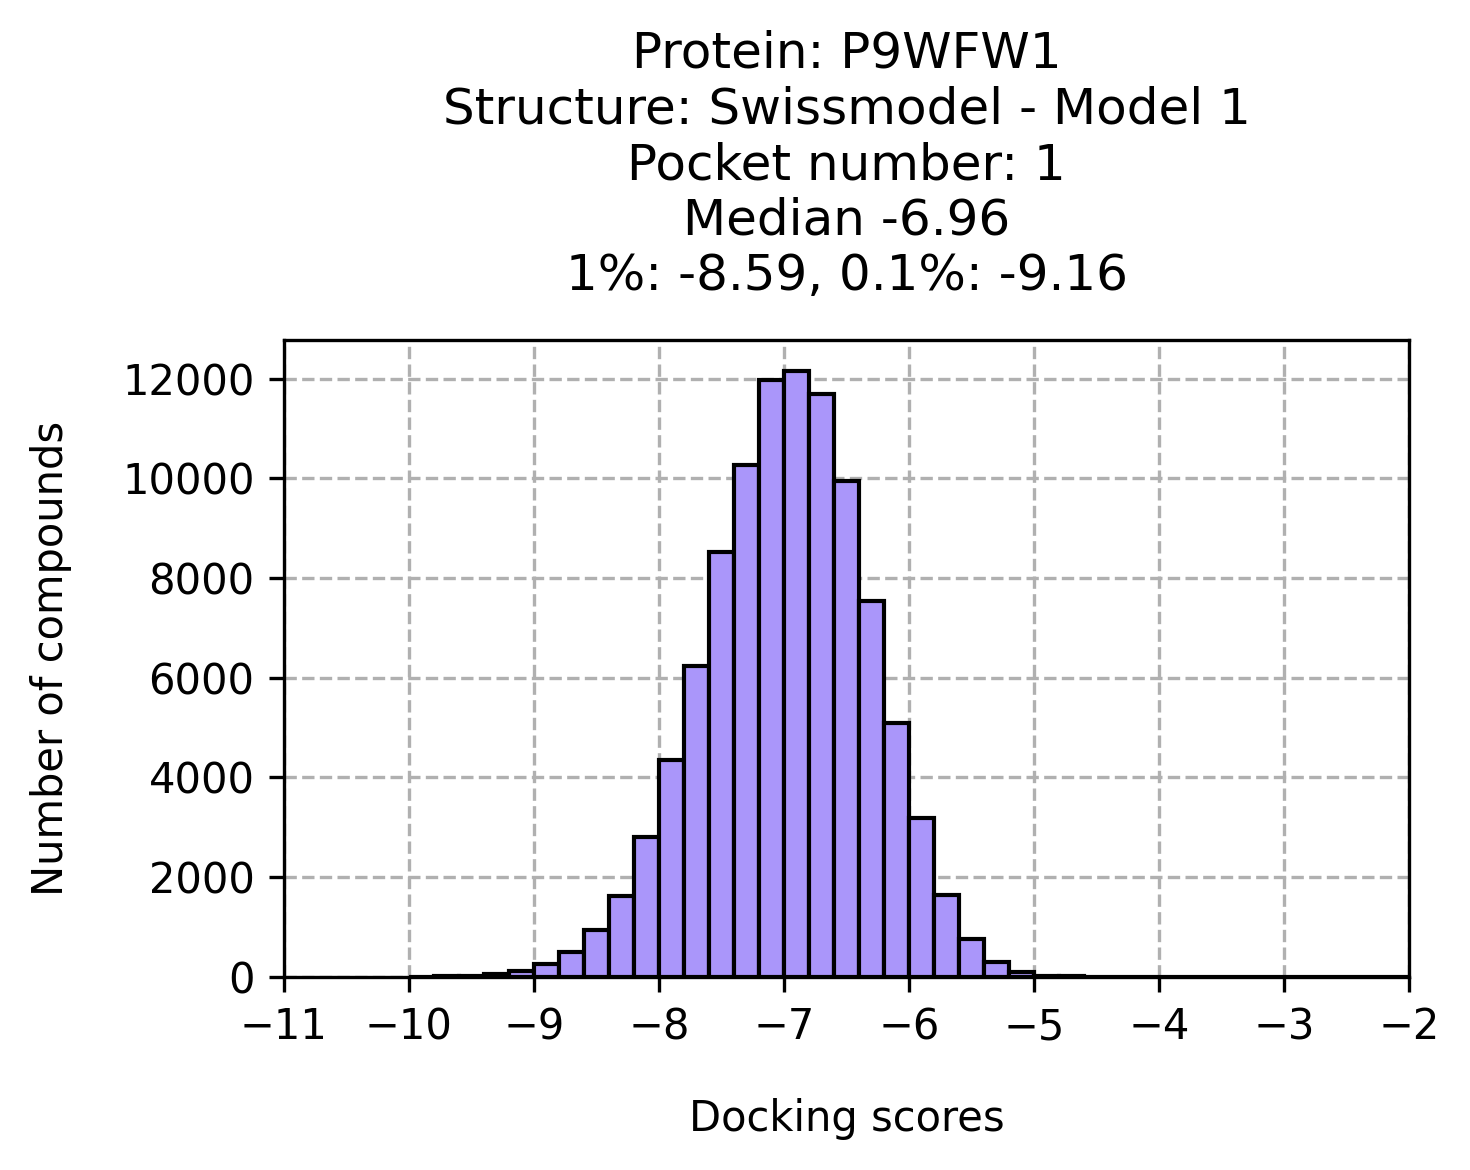

In [6]:
pocket = 'swissmodel_P9WFW1_model_1_pocket_1'
y = list(DOCKING_RESULTS[pocket].values())
bins = [i for i in np.arange(-10, 1, 0.2)]

p = f"Protein: {pocket.split('_')[1]}\nStructure: {pocket.split('_')[0].capitalize()} - Model {pocket.split('_')[3]}\nPocket number: {pocket.split('_')[-1]}"
title = f"{p}\nMedian {round(np.median(y), 2)}\n1%: {round(np.percentile(y, 1), 2)}, 0.1%: {round(np.percentile(y, 0.1), 2)}"

plt.figure(figsize=(5, 4))
plt.hist(y, bins=bins, zorder=2, edgecolor='k', color="#AA96FA")
plt.grid(linestyle='--', zorder=-2)
plt.xlim([-11, -2])
plt.xlabel("Docking scores", labelpad=12)
plt.ylabel("Number of compounds", labelpad=12)
plt.title(title, pad=12)
plt.tight_layout()
plt.show()

In [7]:
### BOXPLOTS ###

In [8]:
def simple_boxplot(ax, x, y, c, width):
    ax.boxplot(y, positions=[x], widths=width, patch_artist=True, whis=[1, 99], showfliers=False,
               boxprops=dict(facecolor=c, color='black', lw=0.25),
               medianprops=dict(color='black', lw=0.25),
               whiskerprops=dict(color='black', lw=0.25),
               capprops=dict(color='none', lw=0.25))

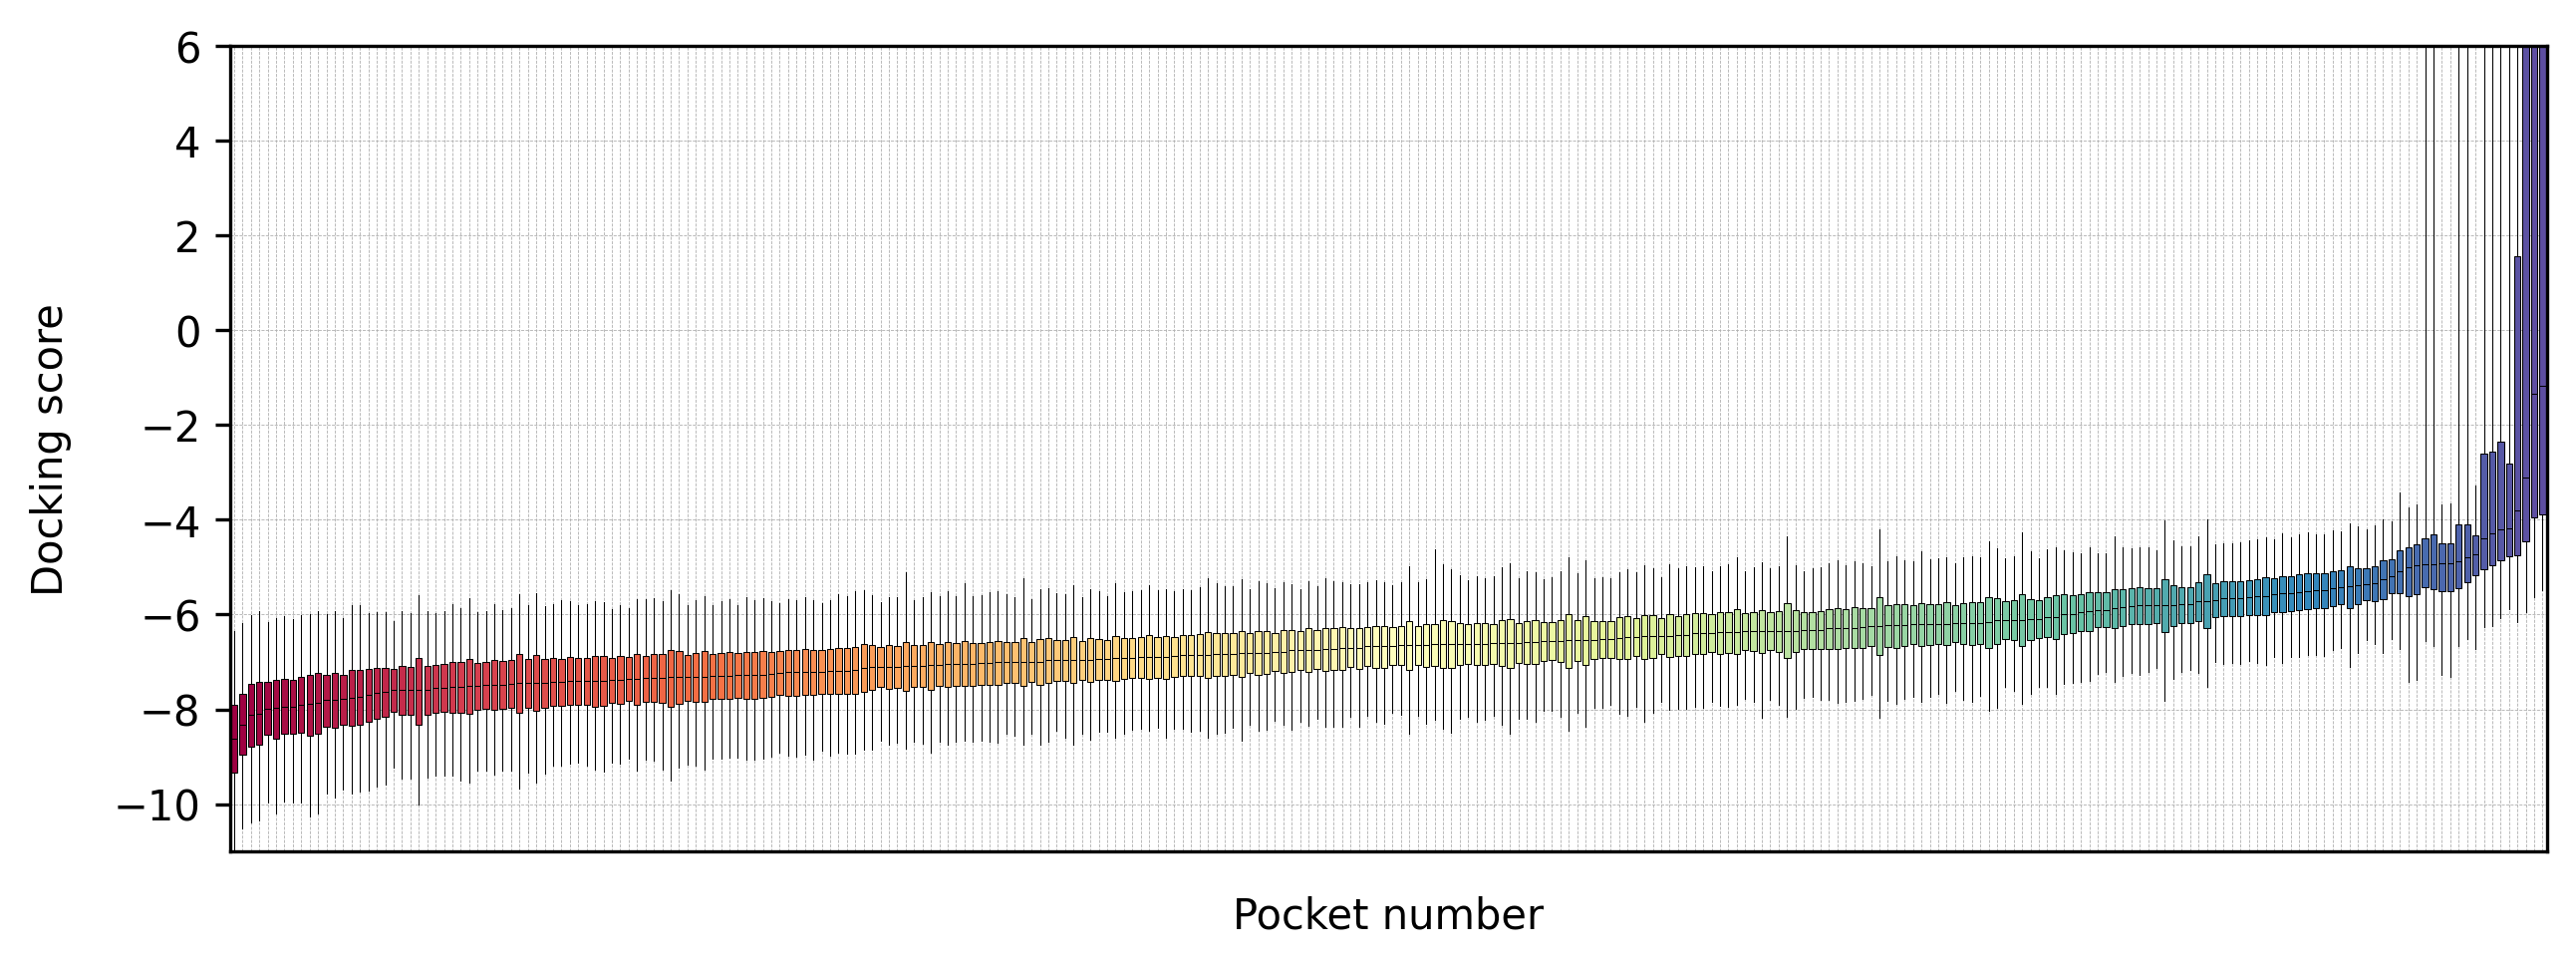

In [9]:
# Sort pockets by median
pockets = sorted(DOCKING_RESULTS)
medians = [np.median(list(DOCKING_RESULTS[p].values())) for p in pockets]
ind = np.argsort(medians)
pockets = np.array(pockets)[ind]

fig, ax = plt.subplots(figsize=(10, 3.5))
colors = cm.Spectral(np.linspace(0, 1, len(pockets)))

for c, pocket in enumerate(pockets):
    simple_boxplot(ax, c, DOCKING_RESULTS[pocket].values(), c=colors[c], width=0.75)

plt.xticks([i for i in range(len(pockets))], ["" for i in range(len(pockets))])
plt.tick_params(axis='x', length=0)
plt.ylim([-11, 6])
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("Docking score", labelpad=10)
plt.show()

In [10]:
### HIT COMPARISON ###

In [11]:
DOCKING_RESULTS_SORTED = {}

# For each pocket
for pocket in tqdm(sorted(DOCKING_RESULTS)):

    # Get compounds sorted by docking score
    sorted_cpds = sorted(DOCKING_RESULTS[pocket], key=lambda x: DOCKING_RESULTS[pocket][x])
    DOCKING_RESULTS_SORTED[pocket] = sorted_cpds

  0%|          | 0/276 [00:00<?, ?it/s]

100%|██████████| 276/276 [00:05<00:00, 47.53it/s]


In [12]:
# Get pocket labels
pockets = [i.replace(".pdb", "") + "_pocket_" + str(j) for i,j in zip(pocket_detection_data['File name'], pocket_detection_data['Pocket number'])]
pockets = [i for i in pockets if i in DOCKING_RESULTS_SORTED]

276it [00:34,  8.02it/s]


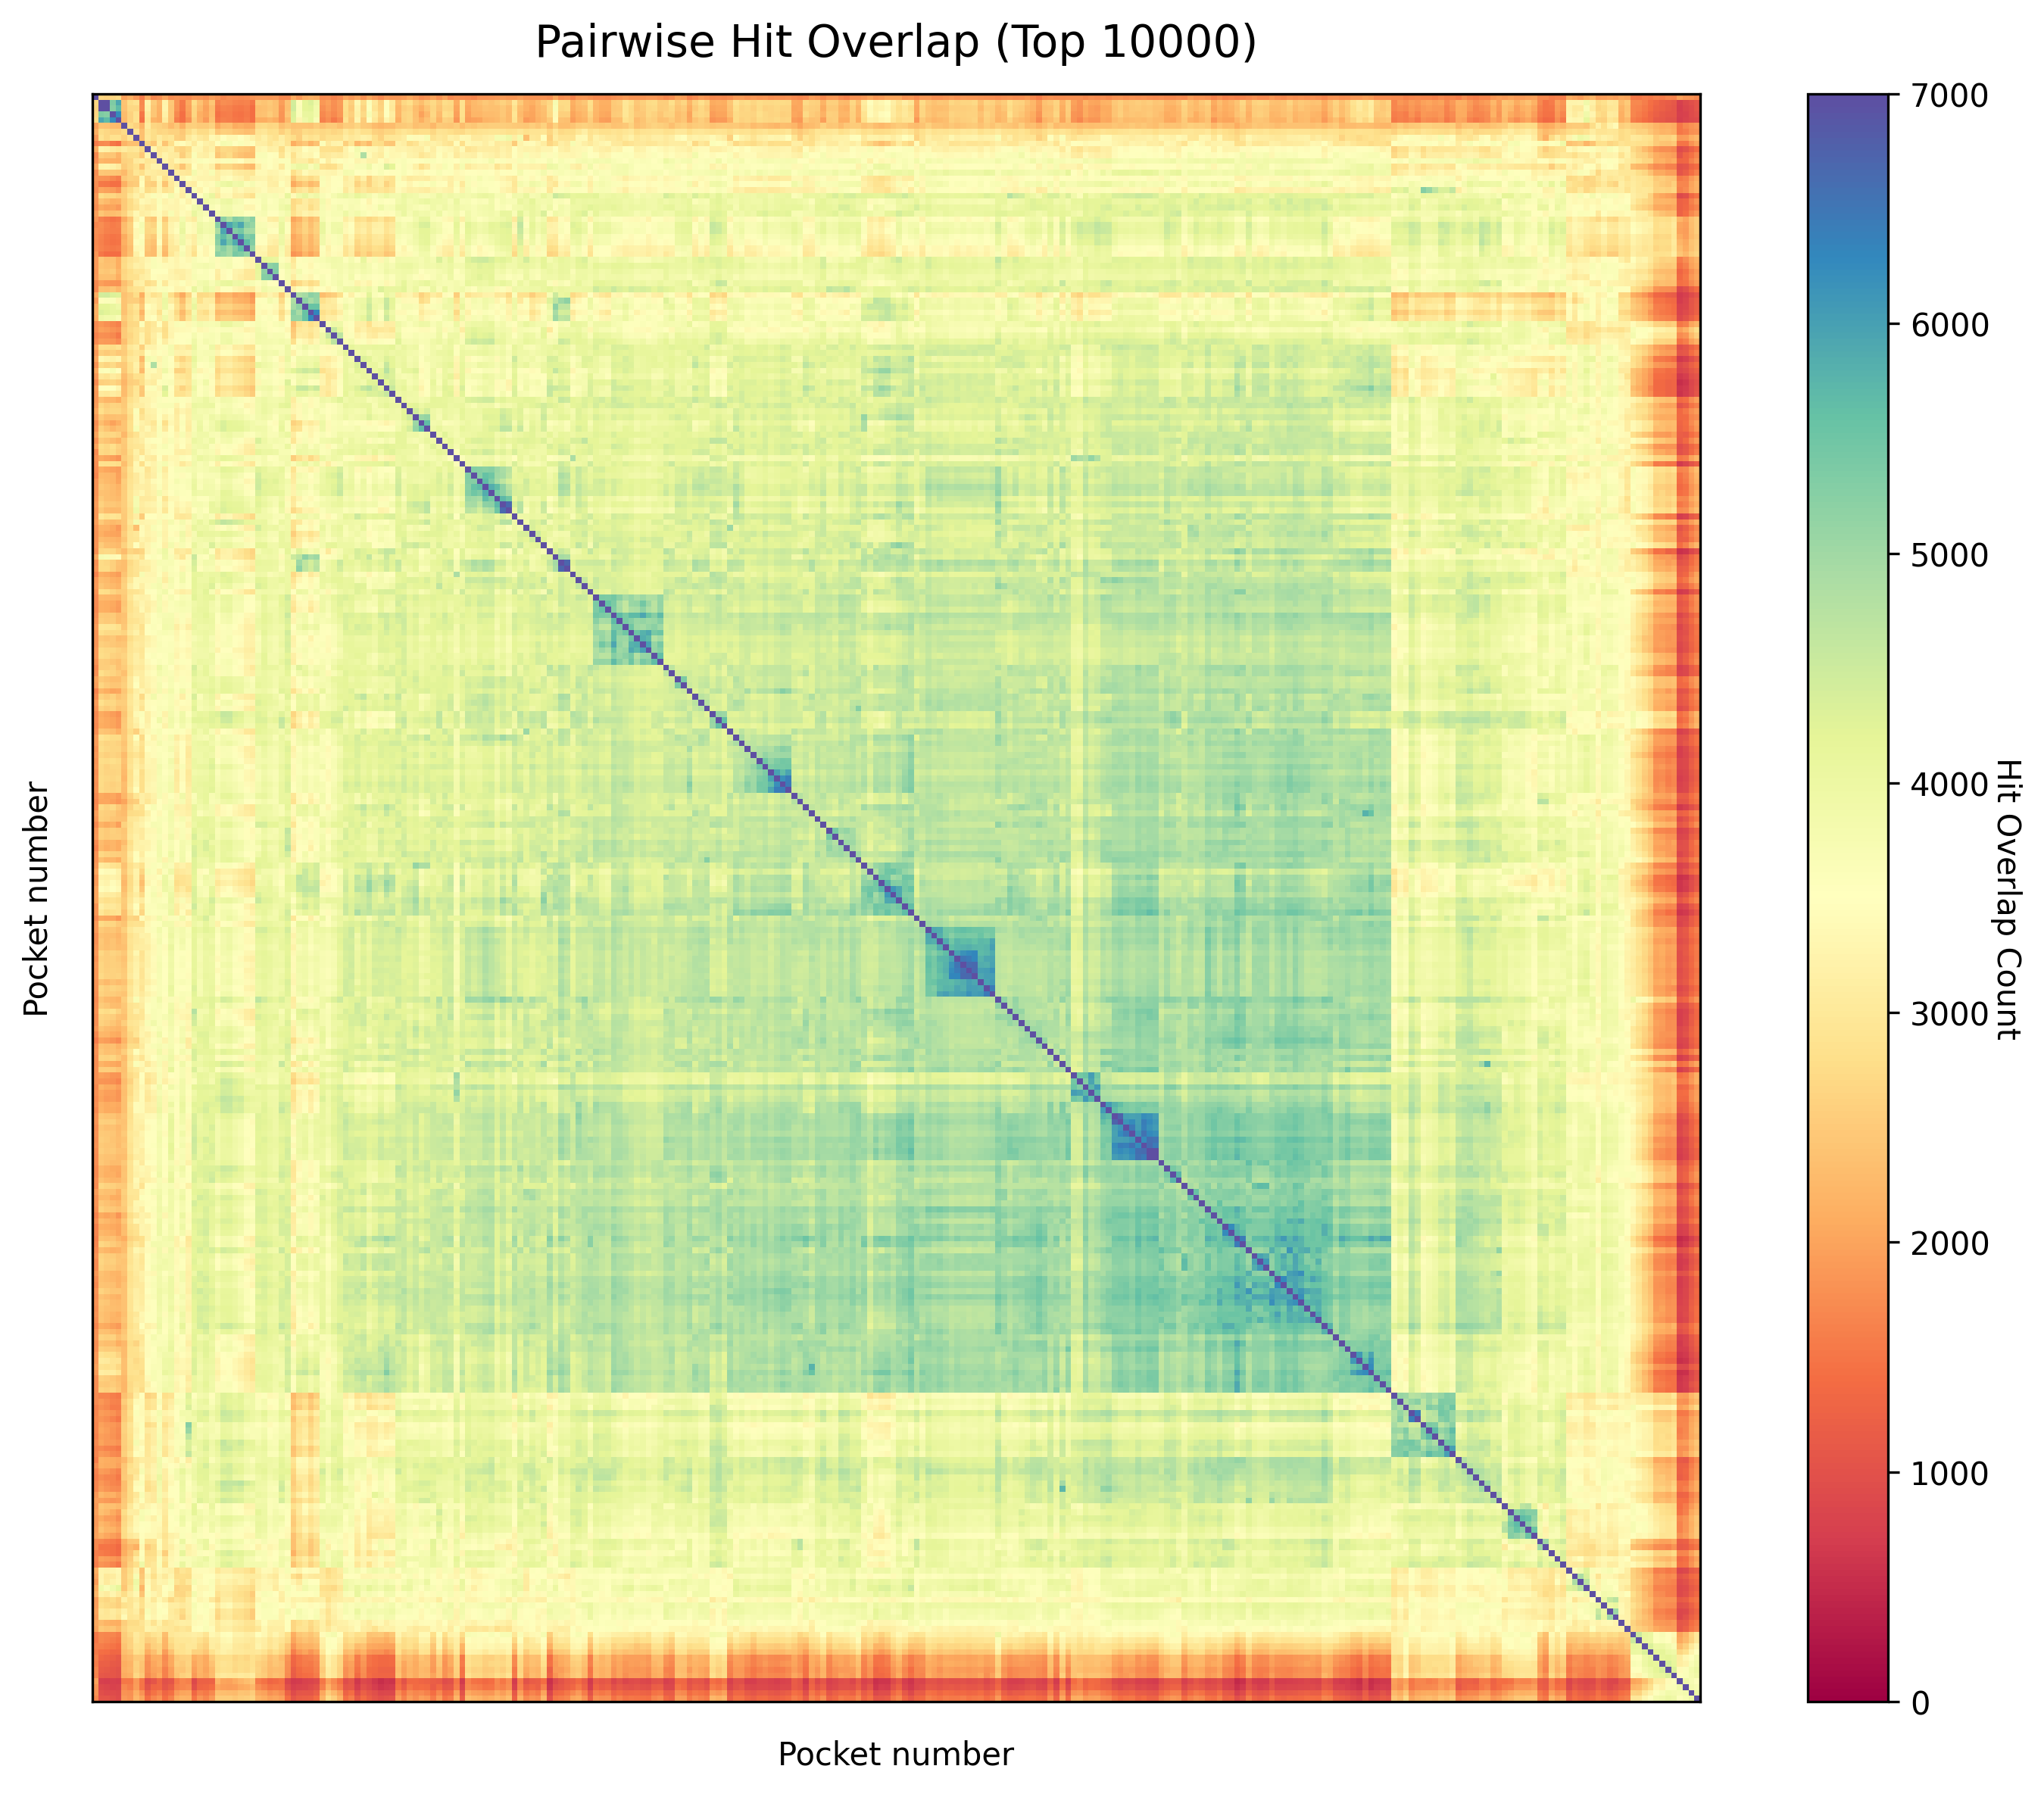

In [13]:
TOP = 10000
HITS_OVERLAP_10000 = {}

# Get hit overlap
for c, pocket1 in tqdm(enumerate(pockets)):
    hits1 = set(DOCKING_RESULTS_SORTED[pocket1][:TOP])
    for pocket2 in pockets[c:]:
        hits2 = set(DOCKING_RESULTS_SORTED[pocket2][:TOP])
        HITS_OVERLAP_10000[(pocket1, pocket2)] = len(hits1.intersection(hits2))
        HITS_OVERLAP_10000[(pocket2, pocket1)] = HITS_OVERLAP_10000[(pocket1, pocket2)]

# Create pairwise matrix
X = np.zeros((len(pockets), len(pockets)))
for c1, pocket1 in enumerate(pockets):
    for c2, pocket2 in enumerate(pockets):
        X[c1][c2] = HITS_OVERLAP_10000[(pocket1, pocket2)]

    
# Create the clustermap
distance_matrix = pdist(X, metric='euclidean')
linkage_matrix = linkage(distance_matrix, method='single')
leaf_order = leaves_list(linkage_matrix)
X_clustermap = X[leaf_order, :][:, leaf_order]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(X_clustermap, cmap='Spectral', vmin=0, vmax=7000)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Hit Overlap Count', rotation=270, labelpad=10)
ax.set_xticks([])
ax.set_yticks([])
plt.xlabel("Pocket number", labelpad=12)
plt.ylabel("Pocket number", labelpad=12)
plt.title(f'Pairwise Hit Overlap (Top {TOP})', pad=12, size=14)
plt.tight_layout()
plt.show()

In [14]:
protein_to_pockets = {i: set() for i in sorted(set(pocket_detection_data['Uniprot AC']))}
pocket_to_coords = {}

for file, pocket_numb, coord in zip(pocket_detection_data['File name'], 
                             pocket_detection_data['Pocket number'],
                             pocket_detection_data['Pocket centroid coordinate (x y z)']):
    
    # Prepare labels
    label = file.replace(".pdb", "") + "_pocket_" + str(pocket_numb)
    protein = file.split("_")[1]

    # Create mappings
    protein_to_pockets[protein].add(label)
    pocket_to_coords[label] = np.array(coord.split(), dtype=float)

# Load pocketvec descriptors
fps_tRNAs = pickle.load(open("../processed/pocketvec_RUN/fps_rank.pkl", 'rb'))

# Get outliers
outliers = {i: len(np.where(fps_tRNAs[i] > 128)[0]) for i in sorted(fps_tRNAs)}

# Filter unreliable tRNA descriptors
fps_tRNAs = {i: fps_tRNAs[i] for i in sorted(fps_tRNAs) if outliers[i] < 80}

# Get list of pairs
pairs = [i for i in sorted(HITS_OVERLAP_10000) if i[0] != i[1] and sorted(i) == list(i) and i[0] in fps_tRNAs and i[1] in fps_tRNAs]

# Get PocketVec distances
distances = {i: float(distance.cosine(fps_tRNAs[i[0]], fps_tRNAs[i[1]])) for i in pairs}

In [15]:
diff_protein_10000, same_protein_10000, same_pocket_10000 = {}, {}, {}

for c, pocket1 in tqdm(enumerate(pockets)):
    for pocket2 in pockets[c+1:]:

        # Define pair
        pair = (pocket1, pocket2)
        
        # If the protein is different
        if pocket1.split("_")[1] != pocket2.split("_")[1]:
            dist = distances[pair] if pair in distances else np.nan
            diff_protein_10000[pair] = [HITS_OVERLAP_10000[pair], dist]

        else:

            # Calculate distance
            d = distance.euclidean(pocket_to_coords[pocket1], pocket_to_coords[pocket2])

            # If the pocket is the same
            if d < 6.14:
                dist = distances[pair] if pair in distances else np.nan
                same_pocket_10000[pair] = [HITS_OVERLAP_10000[pair], dist]

            # If the pocket is not the same
            else:
                dist = distances[pair] if pair in distances else np.nan
                same_protein_10000[pair] = [HITS_OVERLAP_10000[pair], dist]

0it [00:00, ?it/s]

276it [00:00, 466.02it/s]


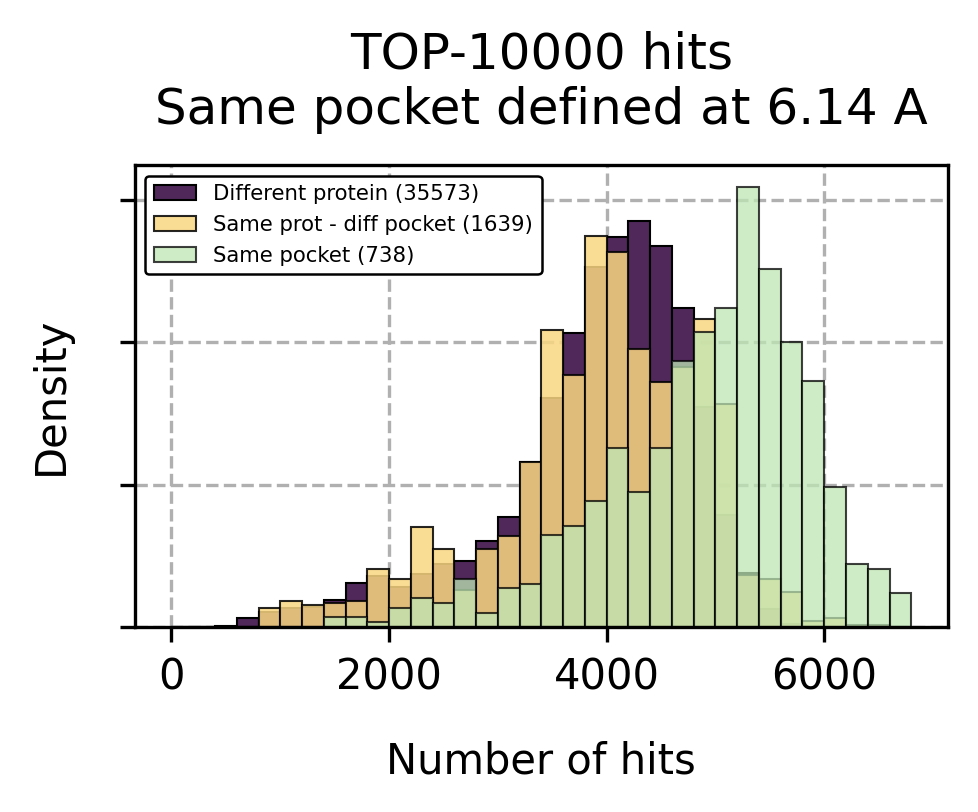

In [16]:
plt.figure(figsize=(3.5, 2))

bins = [i for i in range(0, 7000, 200)]
plt.hist(np.array(list(diff_protein_10000.values()))[:, 0], bins=bins, edgecolor='k', linewidth=0.5, color="#50285A", label=f'Different protein ({len(diff_protein_10000)})', zorder=2, density=True)
plt.hist(np.array(list(same_protein_10000.values()))[:, 0], bins=bins, edgecolor='k', linewidth=0.5, color="#FAD782", label=f'Same prot - diff pocket ({len(same_protein_10000)})', zorder=2, density=True, alpha=0.85)
plt.hist(np.array(list(same_pocket_10000.values()))[:, 0], bins=bins, edgecolor='k', linewidth=0.5, color="#BEE6B4", label=f'Same pocket ({len(same_pocket_10000)})', zorder=2, density=True, alpha=0.75)

title = f'TOP-{TOP} hits' + "\n" + "Same pocket defined at 6.14 A"
plt.title(title, pad=10)
plt.gca().set_yticklabels([])
plt.xlabel("Number of hits", labelpad=10)
plt.ylabel("Density", labelpad=8)
plt.grid(linestyle='--', zorder=-2)
l = plt.legend(framealpha=1, edgecolor='k', prop={'size': 5.1})
l.get_frame().set_linewidth(0.6)
plt.show()

In [55]:
N = np.median(np.array(list(same_pocket_10000.values()))[:,0])
print(len(set([tuple(sorted([i[0].split("_")[1], i[1].split("_")[1]])) for i in diff_protein_10000 if diff_protein_10000[i][0] > N])))

132


In [56]:
##############################################

276it [00:02, 96.55it/s] 


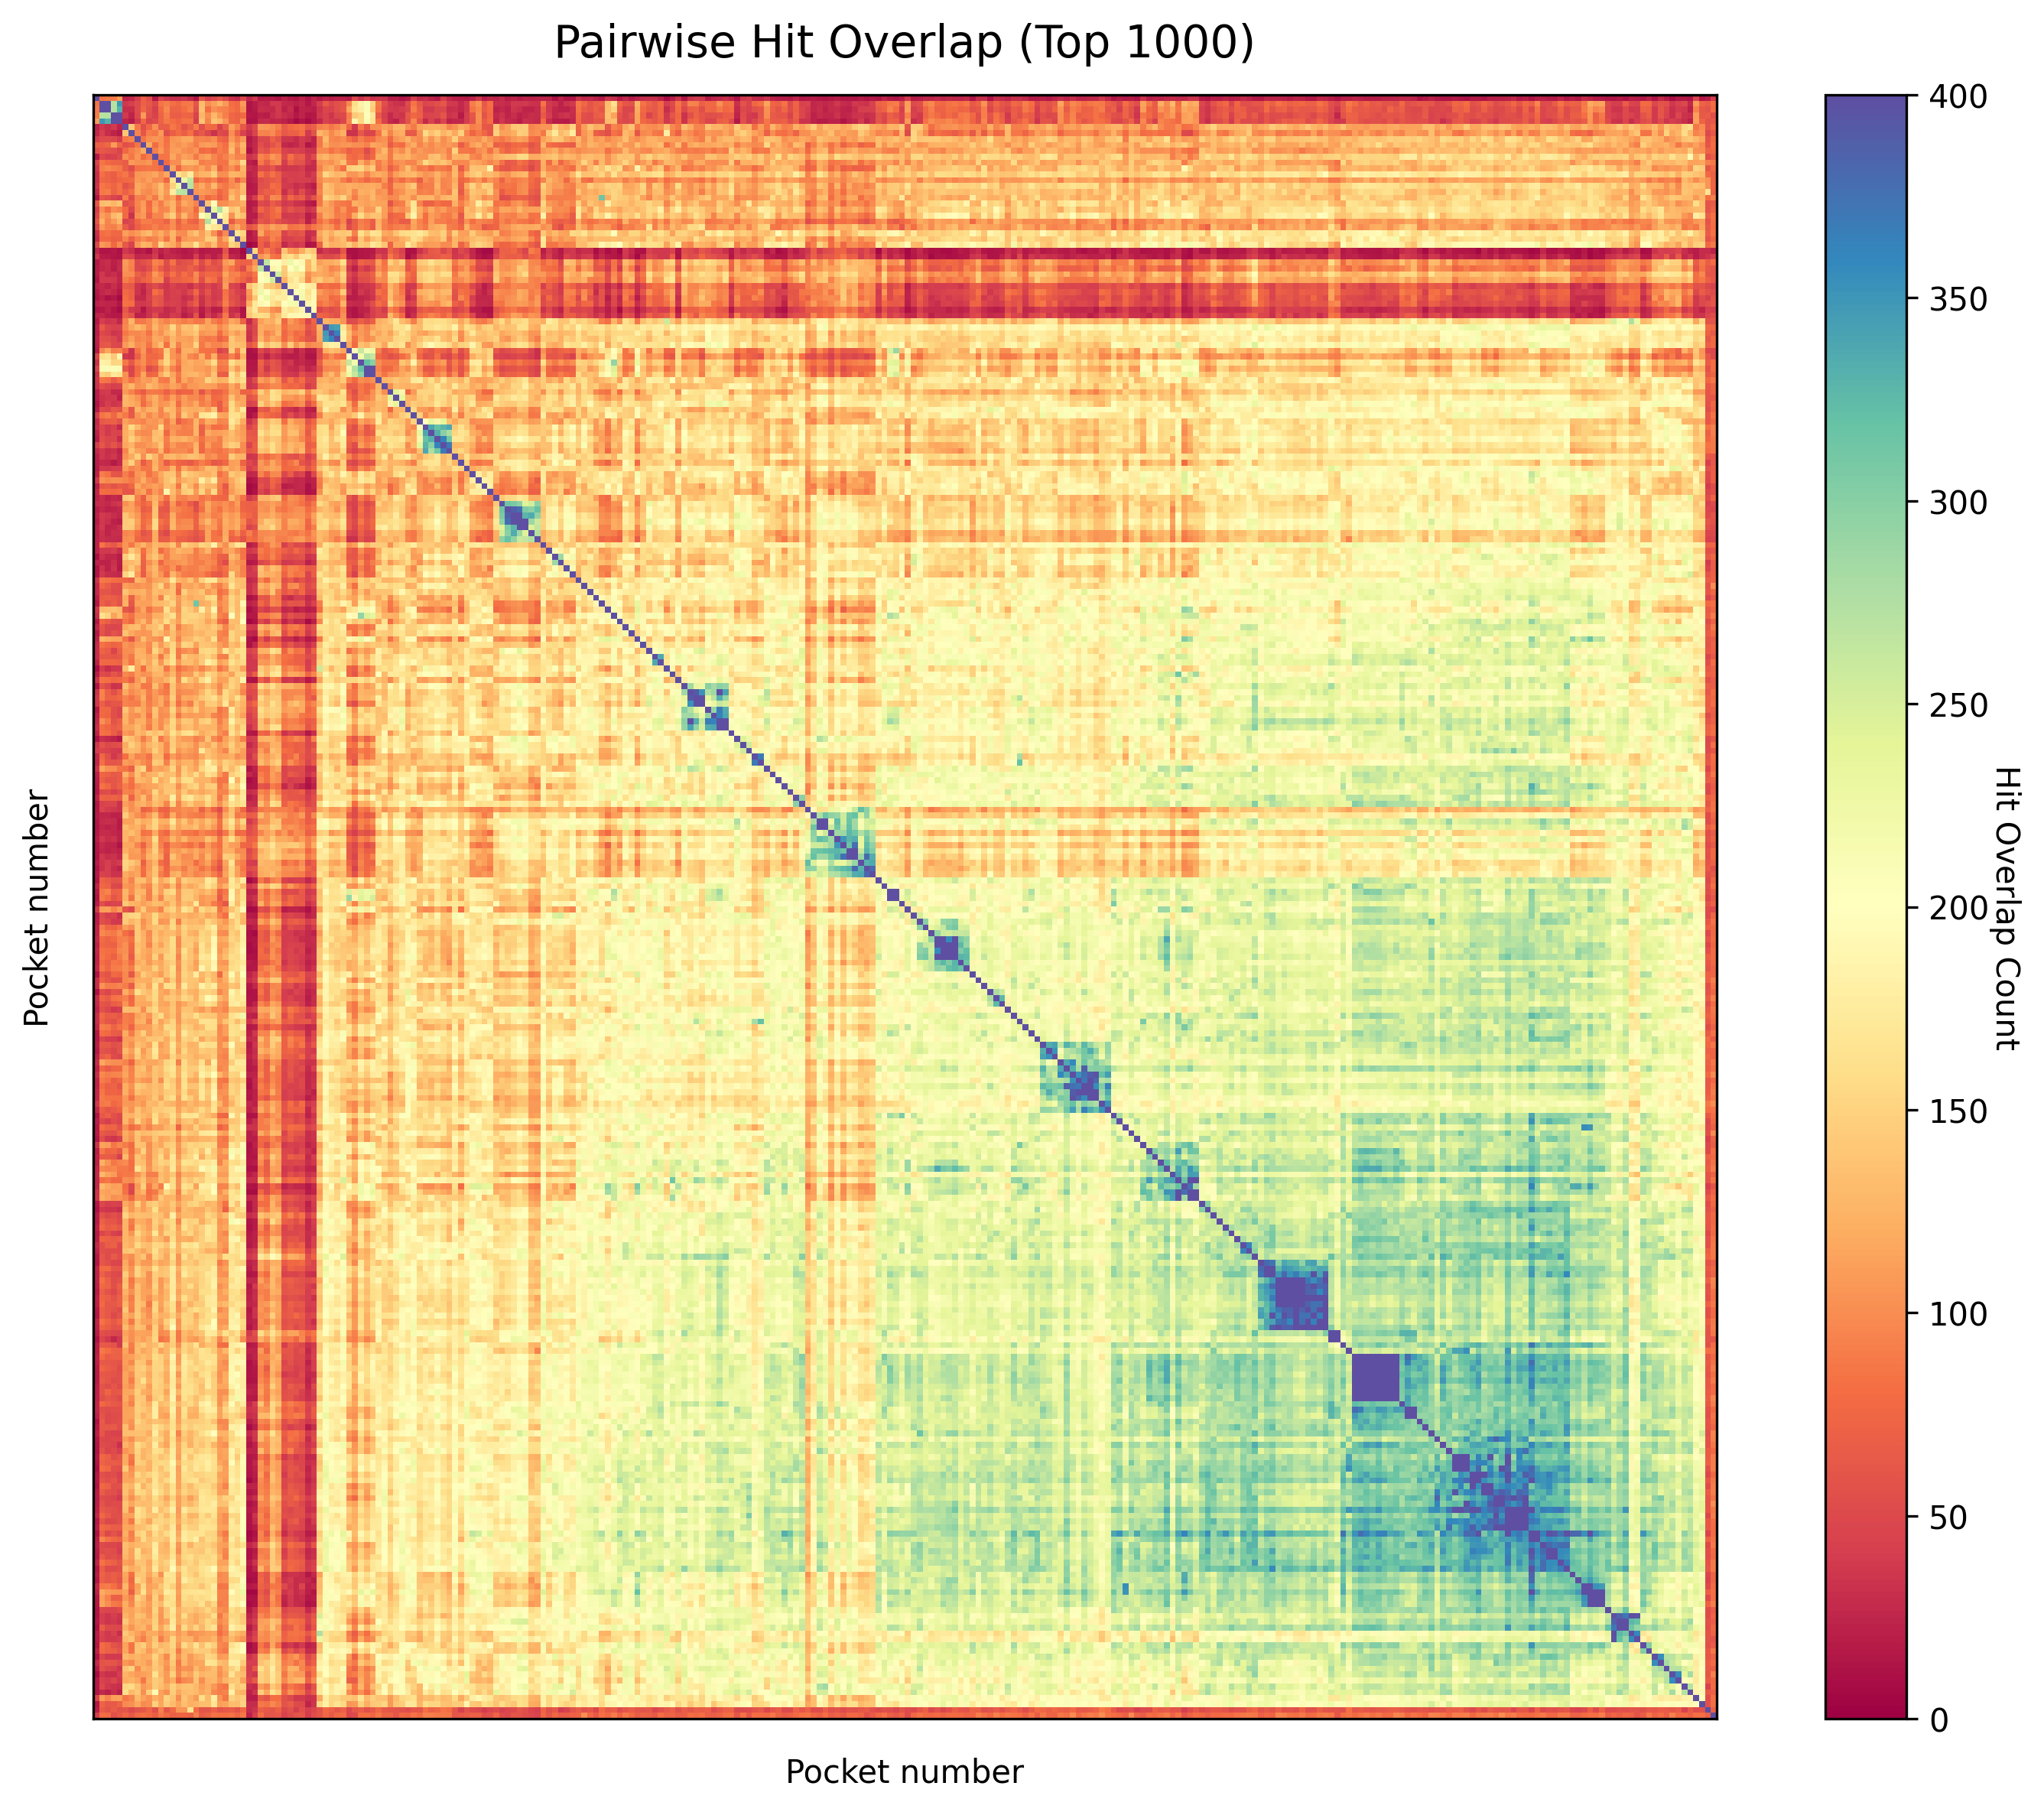

In [57]:
TOP = 1000
HITS_OVERLAP_1000 = {}

# Get hit overlap
for c, pocket1 in tqdm(enumerate(pockets)):
    hits1 = set(DOCKING_RESULTS_SORTED[pocket1][:TOP])
    for pocket2 in pockets[c:]:
        hits2 = set(DOCKING_RESULTS_SORTED[pocket2][:TOP])
        HITS_OVERLAP_1000[(pocket1, pocket2)] = len(hits1.intersection(hits2))
        HITS_OVERLAP_1000[(pocket2, pocket1)] = HITS_OVERLAP_1000[(pocket1, pocket2)]

# Create pairwise matrix
X = np.zeros((len(pockets), len(pockets)))
for c1, pocket1 in enumerate(pockets):
    for c2, pocket2 in enumerate(pockets):
        X[c1][c2] = HITS_OVERLAP_1000[(pocket1, pocket2)]

    
# Create the clustermap
distance_matrix = pdist(X, metric='euclidean')
linkage_matrix = linkage(distance_matrix, method='single')
leaf_order = leaves_list(linkage_matrix)
X_clustermap = X[leaf_order, :][:, leaf_order]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(X_clustermap, cmap='Spectral', vmin=0, vmax=400)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Hit Overlap Count', rotation=270, labelpad=10)
ax.set_xticks([])
ax.set_yticks([])
plt.xlabel("Pocket number", labelpad=12)
plt.ylabel("Pocket number", labelpad=12)
plt.title(f'Pairwise Hit Overlap (Top {TOP})', pad=12, size=14)
plt.tight_layout()
plt.show()

In [58]:
diff_protein_1000, same_protein_1000, same_pocket_1000 = {}, {}, {}

for c, pocket1 in tqdm(enumerate(pockets)):
    for pocket2 in pockets[c+1:]:

        # Define pair
        pair = (pocket1, pocket2)
        
        # If the protein is different
        if pocket1.split("_")[1] != pocket2.split("_")[1]:
            dist = distances[pair] if pair in distances else np.nan
            diff_protein_1000[pair] = [HITS_OVERLAP_1000[pair], dist]

        else:

            # Calculate distance
            d = distance.euclidean(pocket_to_coords[pocket1], pocket_to_coords[pocket2])

            # If the pocket is the same
            if d < 6.14:
                dist = distances[pair] if pair in distances else np.nan
                same_pocket_1000[pair] = [HITS_OVERLAP_1000[pair], dist]

            # If the pocket is not the same
            else:
                dist = distances[pair] if pair in distances else np.nan
                same_protein_1000[pair] = [HITS_OVERLAP_1000[pair], dist]

276it [00:00, 383.80it/s]


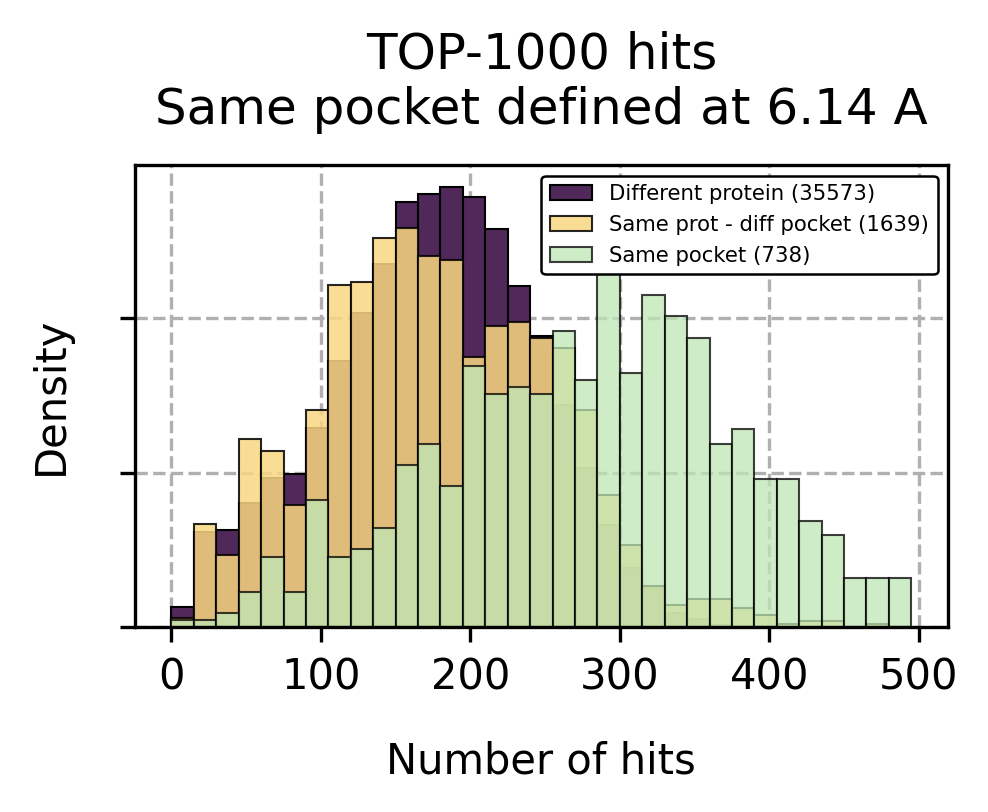

In [59]:
plt.figure(figsize=(3.5, 2))

bins = [i for i in range(0, 500, 15)]
plt.hist(np.array(list(diff_protein_1000.values()))[:, 0], bins=bins, edgecolor='k', linewidth=0.5, color="#50285A", label=f'Different protein ({len(diff_protein_1000)})', zorder=2, density=True)
plt.hist(np.array(list(same_protein_1000.values()))[:, 0], bins=bins, edgecolor='k', linewidth=0.5, color="#FAD782", label=f'Same prot - diff pocket ({len(same_protein_1000)})', zorder=2, density=True, alpha=0.85)
plt.hist(np.array(list(same_pocket_1000.values()))[:, 0], bins=bins, edgecolor='k', linewidth=0.5, color="#BEE6B4", label=f'Same pocket ({len(same_pocket_1000)})', zorder=2, density=True, alpha=0.75)

title = f'TOP-{TOP} hits' + "\n" + "Same pocket defined at 6.14 A"
plt.title(title, pad=10)
plt.gca().set_yticklabels([])
plt.xlabel("Number of hits", labelpad=10)
plt.ylabel("Density", labelpad=8)
plt.grid(linestyle='--', zorder=-2)
l = plt.legend(framealpha=1, edgecolor='k', prop={'size': 5.1})
l.get_frame().set_linewidth(0.6)
plt.show()

In [64]:
N = np.median(np.array(list(same_pocket_1000.values()))[:,0])
print(N)
print(len(set([tuple(sorted([i[0].split("_")[1], i[1].split("_")[1]])) for i in diff_protein_1000 if diff_protein_1000[i][0] > N])))

288.0
149


In [65]:
############################################

0it [00:00, ?it/s]

276it [00:00, 799.21it/s]


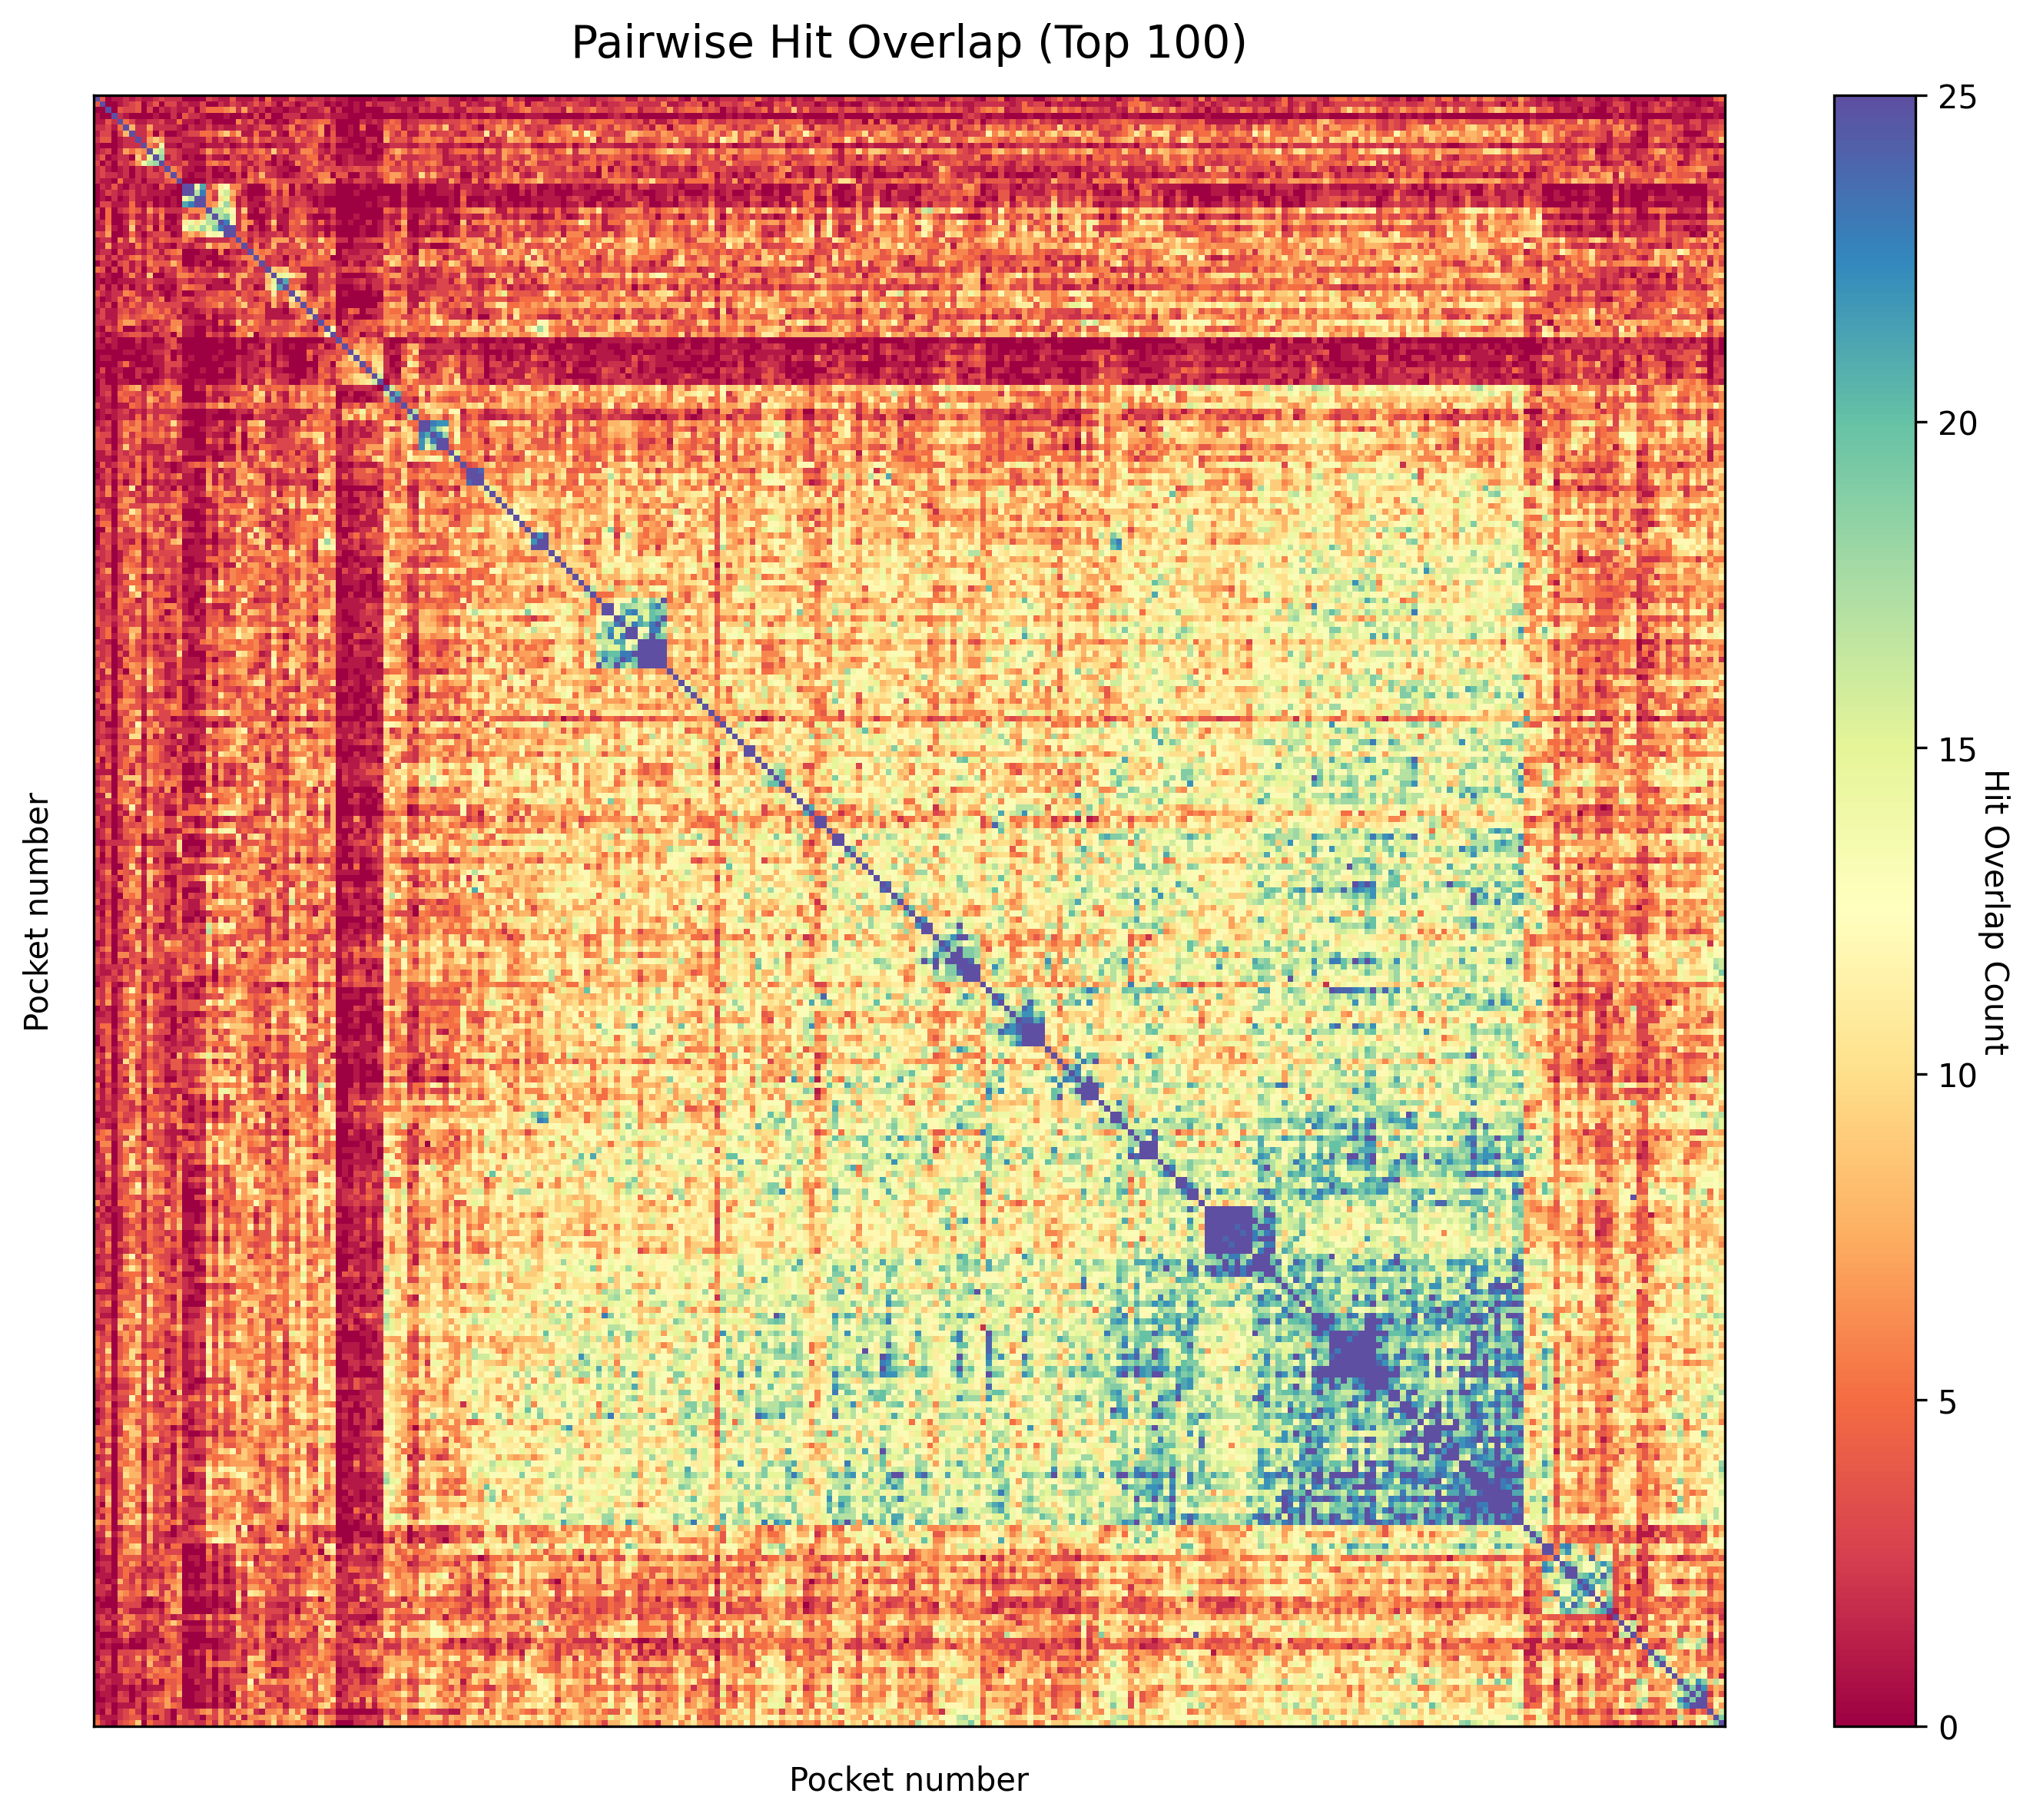

In [66]:
TOP = 100
HITS_OVERLAP_100 = {}

# Get hit overlap
for c, pocket1 in tqdm(enumerate(pockets)):
    hits1 = set(DOCKING_RESULTS_SORTED[pocket1][:TOP])
    for pocket2 in pockets[c:]:
        hits2 = set(DOCKING_RESULTS_SORTED[pocket2][:TOP])
        HITS_OVERLAP_100[(pocket1, pocket2)] = len(hits1.intersection(hits2))
        HITS_OVERLAP_100[(pocket2, pocket1)] = HITS_OVERLAP_100[(pocket1, pocket2)]

# Create pairwise matrix
X = np.zeros((len(pockets), len(pockets)))
for c1, pocket1 in enumerate(pockets):
    for c2, pocket2 in enumerate(pockets):
        X[c1][c2] = HITS_OVERLAP_100[(pocket1, pocket2)]

    
# Create the clustermap
distance_matrix = pdist(X, metric='euclidean')
linkage_matrix = linkage(distance_matrix, method='single')
leaf_order = leaves_list(linkage_matrix)
X_clustermap = X[leaf_order, :][:, leaf_order]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(X_clustermap, cmap='Spectral', vmin=0, vmax=25)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Hit Overlap Count', rotation=270, labelpad=10)
ax.set_xticks([])
ax.set_yticks([])
plt.xlabel("Pocket number", labelpad=12)
plt.ylabel("Pocket number", labelpad=12)
plt.title(f'Pairwise Hit Overlap (Top {TOP})', pad=12, size=14)
plt.tight_layout()
plt.show()

In [67]:
diff_protein_100, same_protein_100, same_pocket_100 = {}, {}, {}

for c, pocket1 in tqdm(enumerate(pockets)):
    for pocket2 in pockets[c+1:]:

        # Define pair
        pair = (pocket1, pocket2)
        
        # If the protein is different
        if pocket1.split("_")[1] != pocket2.split("_")[1]:
            dist = distances[pair] if pair in distances else np.nan
            diff_protein_100[pair] = [HITS_OVERLAP_100[pair], dist]

        else:

            # Calculate distance
            d = distance.euclidean(pocket_to_coords[pocket1], pocket_to_coords[pocket2])

            # If the pocket is the same
            if d < 6.14:
                dist = distances[pair] if pair in distances else np.nan
                same_pocket_100[pair] = [HITS_OVERLAP_100[pair], dist]

            # If the pocket is not the same
            else:
                dist = distances[pair] if pair in distances else np.nan
                same_protein_100[pair] = [HITS_OVERLAP_100[pair], dist]

276it [00:00, 6737.96it/s]


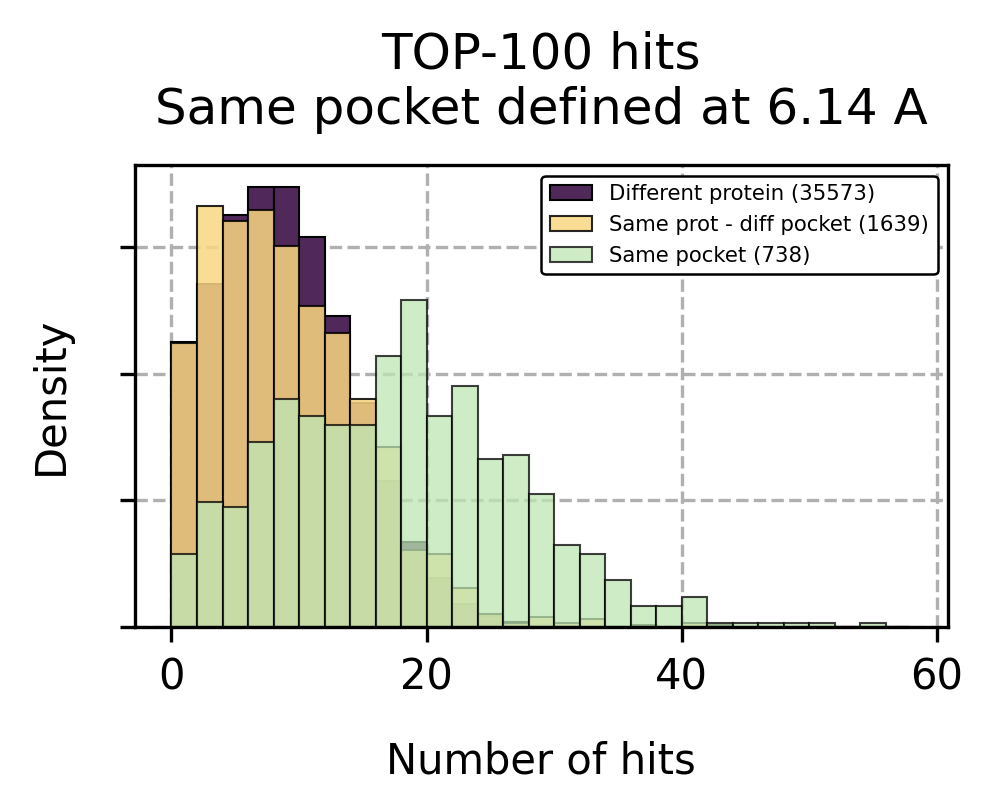

In [68]:
plt.figure(figsize=(3.5, 2))

bins = [i for i in range(0, 60, 2)]
plt.hist(np.array(list(diff_protein_100.values()))[:, 0], bins=bins, edgecolor='k', linewidth=0.5, color="#50285A", label=f'Different protein ({len(diff_protein_100)})', zorder=2, density=True)
plt.hist(np.array(list(same_protein_100.values()))[:, 0], bins=bins, edgecolor='k', linewidth=0.5, color="#FAD782", label=f'Same prot - diff pocket ({len(same_protein_100)})', zorder=2, density=True, alpha=0.85)
plt.hist(np.array(list(same_pocket_100.values()))[:, 0], bins=bins, edgecolor='k', linewidth=0.5, color="#BEE6B4", label=f'Same pocket ({len(same_pocket_100)})', zorder=2, density=True, alpha=0.75)

title = f'TOP-{TOP} hits' + "\n" + "Same pocket defined at 6.14 A"
plt.title(title, pad=10)
plt.gca().set_yticklabels([])
plt.xlabel("Number of hits", labelpad=10)
plt.ylabel("Density", labelpad=8)
plt.grid(linestyle='--', zorder=-2)
l = plt.legend(framealpha=1, edgecolor='k', prop={'size': 5.1})
l.get_frame().set_linewidth(0.6)
plt.show()

In [69]:
N = np.median(np.array(list(same_pocket_100.values()))[:,0])
print(N)
print(len(set([tuple(sorted([i[0].split("_")[1], i[1].split("_")[1]])) for i in diff_protein_100 if diff_protein_100[i][0] > N])))

17.0
198


In [ ]:
### POCKETVEC DISTANCE ###

In [ ]:
# Load pocketvec descriptors
fps_tRNAs = pickle.load(open("../processed/pocketvec_RUN/fps_rank.pkl", 'rb'))

# Get outliers
outliers = {i: len(np.where(fps_tRNAs[i] > 128)[0]) for i in sorted(fps_tRNAs)}

# Filter unreliable tRNA descriptors
fps_tRNAs = {i: fps_tRNAs[i] for i in sorted(fps_tRNAs) if outliers[i] < 80}

# Get list of pairs
pairs = [i for i in sorted(HITS_OVERLAP_10000) if i[0] != i[1] and sorted(i) == list(i) and i[0] in fps_tRNAs and i[1] in fps_tRNAs]

# Get PocketVec distances
distances = {i: float(distance.cosine(fps_tRNAs[i[0]], fps_tRNAs[i[1]])) for i in pairs}

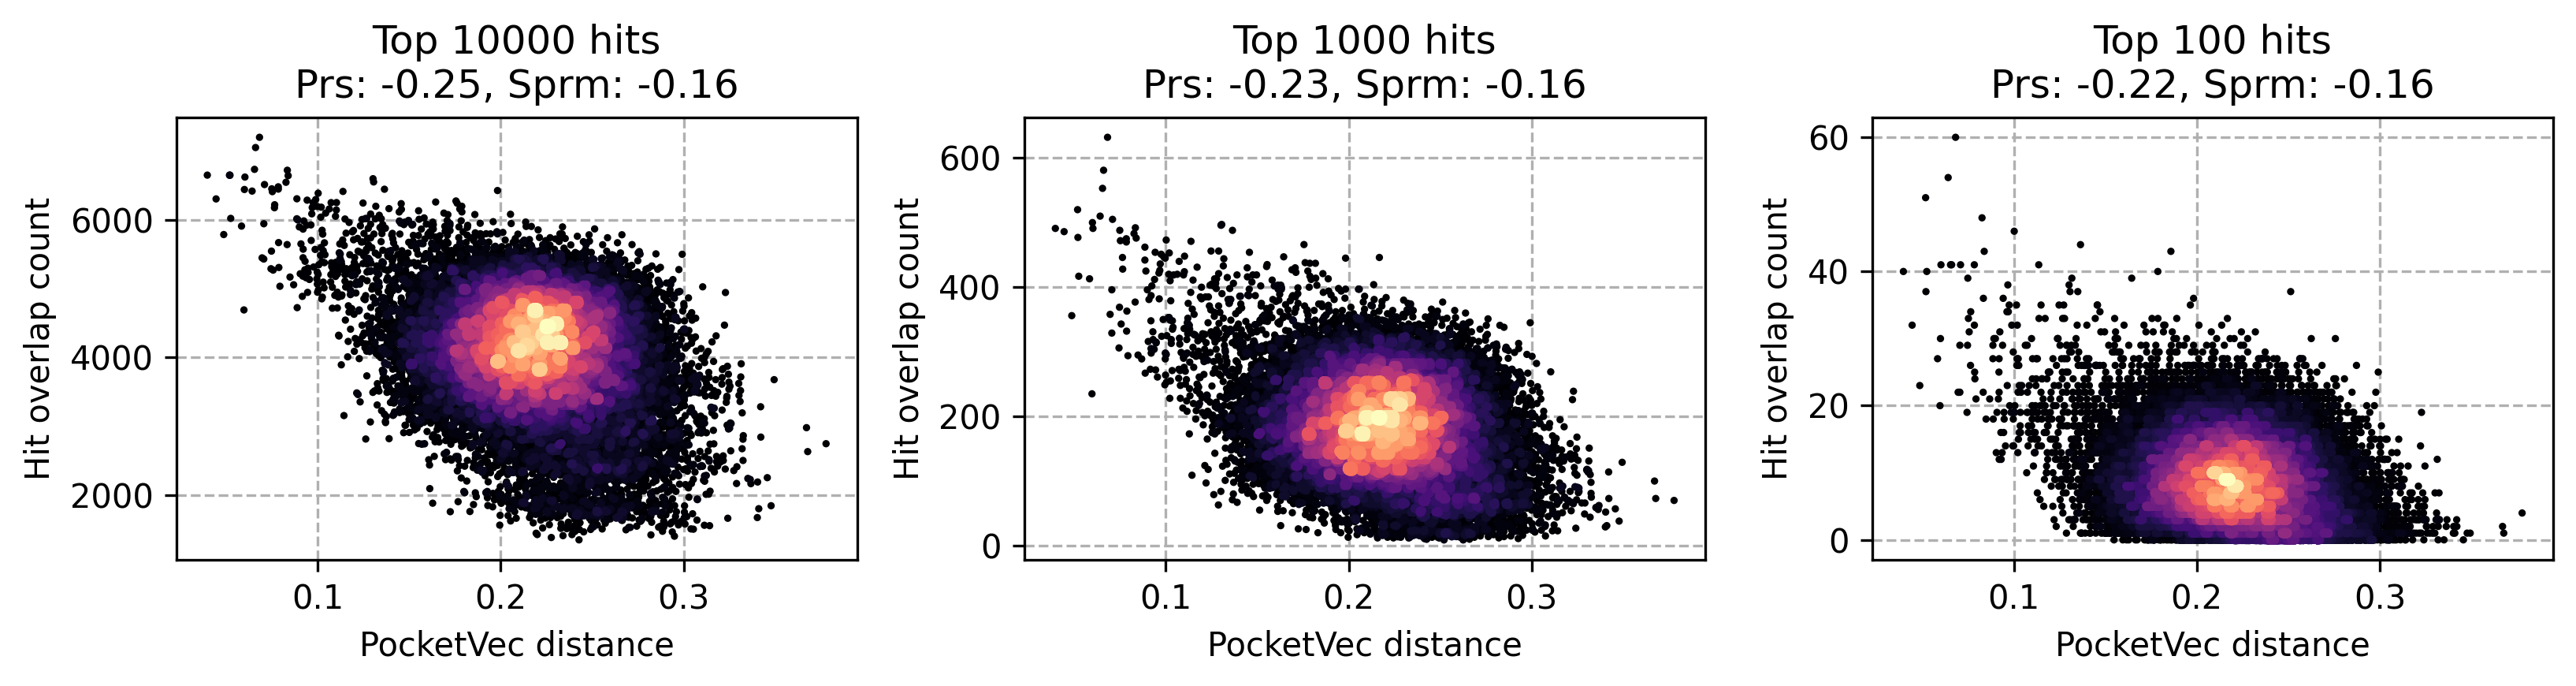

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3))

# 10000
x = [distances[i] for i in pairs]
y = [HITS_OVERLAP_10000[i] for i in pairs]
bins = 150  # adjust for granularity
counts, xedges, yedges = np.histogram2d(x, y, bins=bins)
x_bin = np.digitize(x, xedges) - 1
y_bin = np.digitize(y, yedges) - 1
x_bin = np.clip(x_bin, 0, bins-1)
y_bin = np.clip(y_bin, 0, bins-1)
density = counts[x_bin, y_bin]
sizes = 5 + 10*(density - density.min()) / (density.max() - density.min())
colors = density
inds = np.argsort(sizes)
ax[0].scatter(np.array(x)[inds], np.array(y)[inds], c=colors[inds], s=sizes[inds], cmap='magma', zorder=2, lw=0)
ax[0].set_xlabel("PocketVec distance")
ax[0].set_ylabel("Hit overlap count")
ax[0].grid(linestyle='--', zorder=-2)
pearson = ss.pearsonr(x,y).statistic
spearman = ss.spearmanr(x,y).statistic
ax[0].set_title(f"Top 10000 hits\nPrs: {round(pearson, 2)}, Sprm: {round(spearman, 2)}")

# 1000
x = [distances[i] for i in pairs]
y = [HITS_OVERLAP_1000[i] for i in pairs]
bins = 150  # adjust for granularity
counts, xedges, yedges = np.histogram2d(x, y, bins=bins)
x_bin = np.digitize(x, xedges) - 1
y_bin = np.digitize(y, yedges) - 1
x_bin = np.clip(x_bin, 0, bins-1)
y_bin = np.clip(y_bin, 0, bins-1)
density = counts[x_bin, y_bin]
sizes = 5 + 10*(density - density.min()) / (density.max() - density.min())
colors = density
inds = np.argsort(sizes)
ax[1].scatter(np.array(x)[inds], np.array(y)[inds], c=colors[inds], s=sizes[inds], cmap='magma', zorder=2, lw=0)
ax[1].set_xlabel("PocketVec distance")
ax[1].set_ylabel("Hit overlap count")
ax[1].grid(linestyle='--', zorder=-2)
pearson = ss.pearsonr(x,y).statistic
spearman = ss.spearmanr(x,y).statistic
ax[1].set_title(f"Top 1000 hits\nPrs: {round(pearson, 2)}, Sprm: {round(spearman, 2)}")

# 100
x = [distances[i] for i in pairs]
y = [HITS_OVERLAP_100[i] for i in pairs]
bins = 150  # adjust for granularity
counts, xedges, yedges = np.histogram2d(x, y, bins=bins)
x_bin = np.digitize(x, xedges) - 1
y_bin = np.digitize(y, yedges) - 1
x_bin = np.clip(x_bin, 0, bins-1)
y_bin = np.clip(y_bin, 0, bins-1)
density = counts[x_bin, y_bin]
sizes = 5 + 10*(density - density.min()) / (density.max() - density.min())
colors = density
inds = np.argsort(sizes)
ax[2].scatter(np.array(x)[inds], np.array(y)[inds], c=colors[inds], s=sizes[inds], cmap='magma', zorder=2, lw=0)
ax[2].set_xlabel("PocketVec distance")
ax[2].set_ylabel("Hit overlap count")
ax[2].grid(linestyle='--', zorder=-2)
pearson = ss.pearsonr(x,y).statistic
spearman = ss.spearmanr(x,y).statistic
ax[2].set_title(f"Top 100 hits\nPrs: {round(pearson, 2)}, Sprm: {round(spearman, 2)}")


plt.tight_layout()
plt.show()

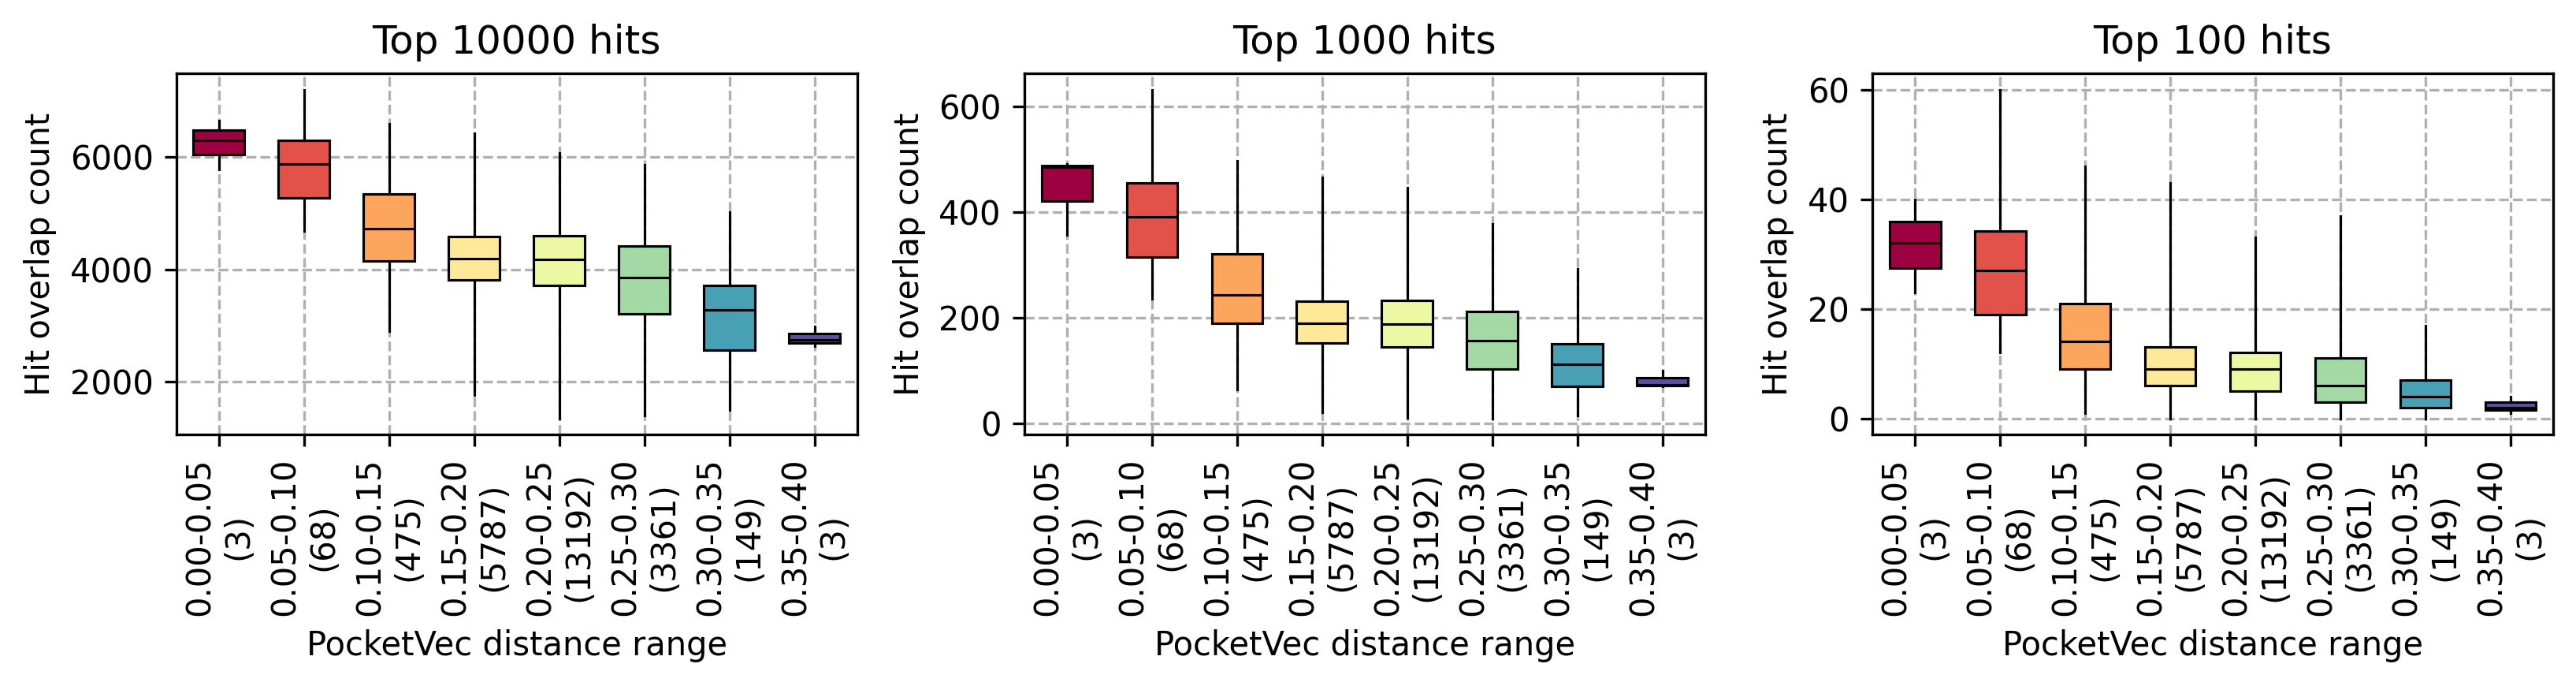

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(11, 3))

# 10000
r = np.linspace(0, 0.4, 9)
xticks = {c: f"{r[c]:.2f}-{r[c+1]:.2f}" for c, i in enumerate(r[:-1])}
colors = cm.Spectral(np.linspace(0, 1, len(r)-1))
for c, i in enumerate(r[:-1]):
    in_a = [diff_protein_10000[i][0] for i in diff_protein_10000 if diff_protein_10000[i][1] > r[c] and diff_protein_10000[i][1] < r[c+1]]
    in_b = [same_protein_10000[i][0] for i in same_protein_10000 if same_protein_10000[i][1] > r[c] and same_protein_10000[i][1] < r[c+1]]
    in_c = [same_pocket_10000[i][0] for i in same_pocket_10000 if same_pocket_10000[i][1] > r[c] and same_pocket_10000[i][1] < r[c+1]]
    simple_boxplot(ax[0], c, in_a + in_b + in_c, c=colors[c], width=0.6)
    xticks[c] += f"\n({len(in_a) + len(in_b) + len(in_c)})"

ax[0].set_xlabel("PocketVec distance range")
ax[0].set_ylabel("Hit overlap count")
ax[0].grid(linestyle='--', zorder=-2)
ax[0].set_title(f"Top 10000 hits")
ax[0].set_xticks([i for i in range(len(r)-1)], [xticks[i] for i in range(len(r)-1)], rotation=90, size=10)


# 1000
r = np.linspace(0, 0.4, 9)
xticks = {c: f"{r[c]:.2f}-{r[c+1]:.2f}" for c, i in enumerate(r[:-1])}
colors = cm.Spectral(np.linspace(0, 1, len(r)-1))
for c, i in enumerate(r[:-1]):
    in_a = [diff_protein_1000[i][0] for i in diff_protein_1000 if diff_protein_1000[i][1] > r[c] and diff_protein_1000[i][1] < r[c+1]]
    in_b = [same_protein_1000[i][0] for i in same_protein_1000 if same_protein_1000[i][1] > r[c] and same_protein_1000[i][1] < r[c+1]]
    in_c = [same_pocket_1000[i][0] for i in same_pocket_1000 if same_pocket_1000[i][1] > r[c] and same_pocket_1000[i][1] < r[c+1]]
    simple_boxplot(ax[1], c, in_a + in_b + in_c, c=colors[c], width=0.6)
    xticks[c] += f"\n({len(in_a) + len(in_b) + len(in_c)})"

ax[1].set_xlabel("PocketVec distance range")
ax[1].set_ylabel("Hit overlap count")
ax[1].grid(linestyle='--', zorder=-2)
ax[1].set_title(f"Top 1000 hits")
ax[1].set_xticks([i for i in range(len(r)-1)], [xticks[i] for i in range(len(r)-1)], rotation=90, size=10)


# 100
r = np.linspace(0, 0.4, 9)
xticks = {c: f"{r[c]:.2f}-{r[c+1]:.2f}" for c, i in enumerate(r[:-1])}
colors = cm.Spectral(np.linspace(0, 1, len(r)-1))
for c, i in enumerate(r[:-1]):
    in_a = [diff_protein_100[i][0] for i in diff_protein_100 if diff_protein_100[i][1] > r[c] and diff_protein_100[i][1] < r[c+1]]
    in_b = [same_protein_100[i][0] for i in same_protein_100 if same_protein_100[i][1] > r[c] and same_protein_100[i][1] < r[c+1]]
    in_c = [same_pocket_100[i][0] for i in same_pocket_100 if same_pocket_100[i][1] > r[c] and same_pocket_100[i][1] < r[c+1]]
    simple_boxplot(ax[2], c, in_a + in_b + in_c, c=colors[c], width=0.6)
    xticks[c] += f"\n({len(in_a) + len(in_b) + len(in_c)})"

ax[2].set_xlabel("PocketVec distance range")
ax[2].set_ylabel("Hit overlap count")
ax[2].grid(linestyle='--', zorder=-2)
ax[2].set_title(f"Top 100 hits")
ax[2].set_xticks([i for i in range(len(r)-1)], [xticks[i] for i in range(len(r)-1)], rotation=90, size=10)

plt.tight_layout()
plt.show()

In [4]:
### CORRELATION WITH PHYSICOCHEMICAL PROPERTIES ###

In [5]:
# Load ID to SMILES mapping
ID_TO_SMI = pickle.load(open(os.path.join("..", "processed", "enamine_characterization", "ID_TO_SMI.pkl"), "rb"))
ids = sorted(ID_TO_SMI)

# Init dicts
ID_TO_MW, ID_TO_LOGP, ID_TO_TPSA = {}, {}, {}

# Calculate physicochemical properties
for id_ in tqdm(ids):
    mol = Chem.MolFromSmiles(ID_TO_SMI[id_])
    ID_TO_MW[id_] = Descriptors.MolWt(mol)
    ID_TO_LOGP[id_] = Descriptors.MolLogP(mol)
    ID_TO_TPSA[id_] = Descriptors.TPSA(mol)

# Load docking results
PATH_TO_DOCKING_RESULTS = os.path.join("..", "processed", "unidock_docking", 'docking_results')
ST_TO_DOCKING_SCORE = {}
for st in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS))):
    # Load and store docking scores
    report = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS, st, 'report.csv'))
    ST_TO_DOCKING_SCORE[st] = {i: j for i, j in zip(report['compound'], report['score'])}

100%|██████████| 276/276 [00:13<00:00, 20.59it/s]


In [6]:
def calculate_density(x, y, bandwidth):
    xy = np.stack([x,y])
    kde = gaussian_kde(xy, bw_method=bandwidth)
    density = kde(xy)
    ind = np.argsort(density)
    x_sorted = np.array(x)[ind]
    y_sorted = np.array(y)[ind]
    density_sorted = density[ind]
    sizes = 1 + 9*(density_sorted - density_sorted.min()) / (density_sorted.max() - density_sorted.min())
    colors = density_sorted
    return x_sorted, y_sorted, colors, sizes

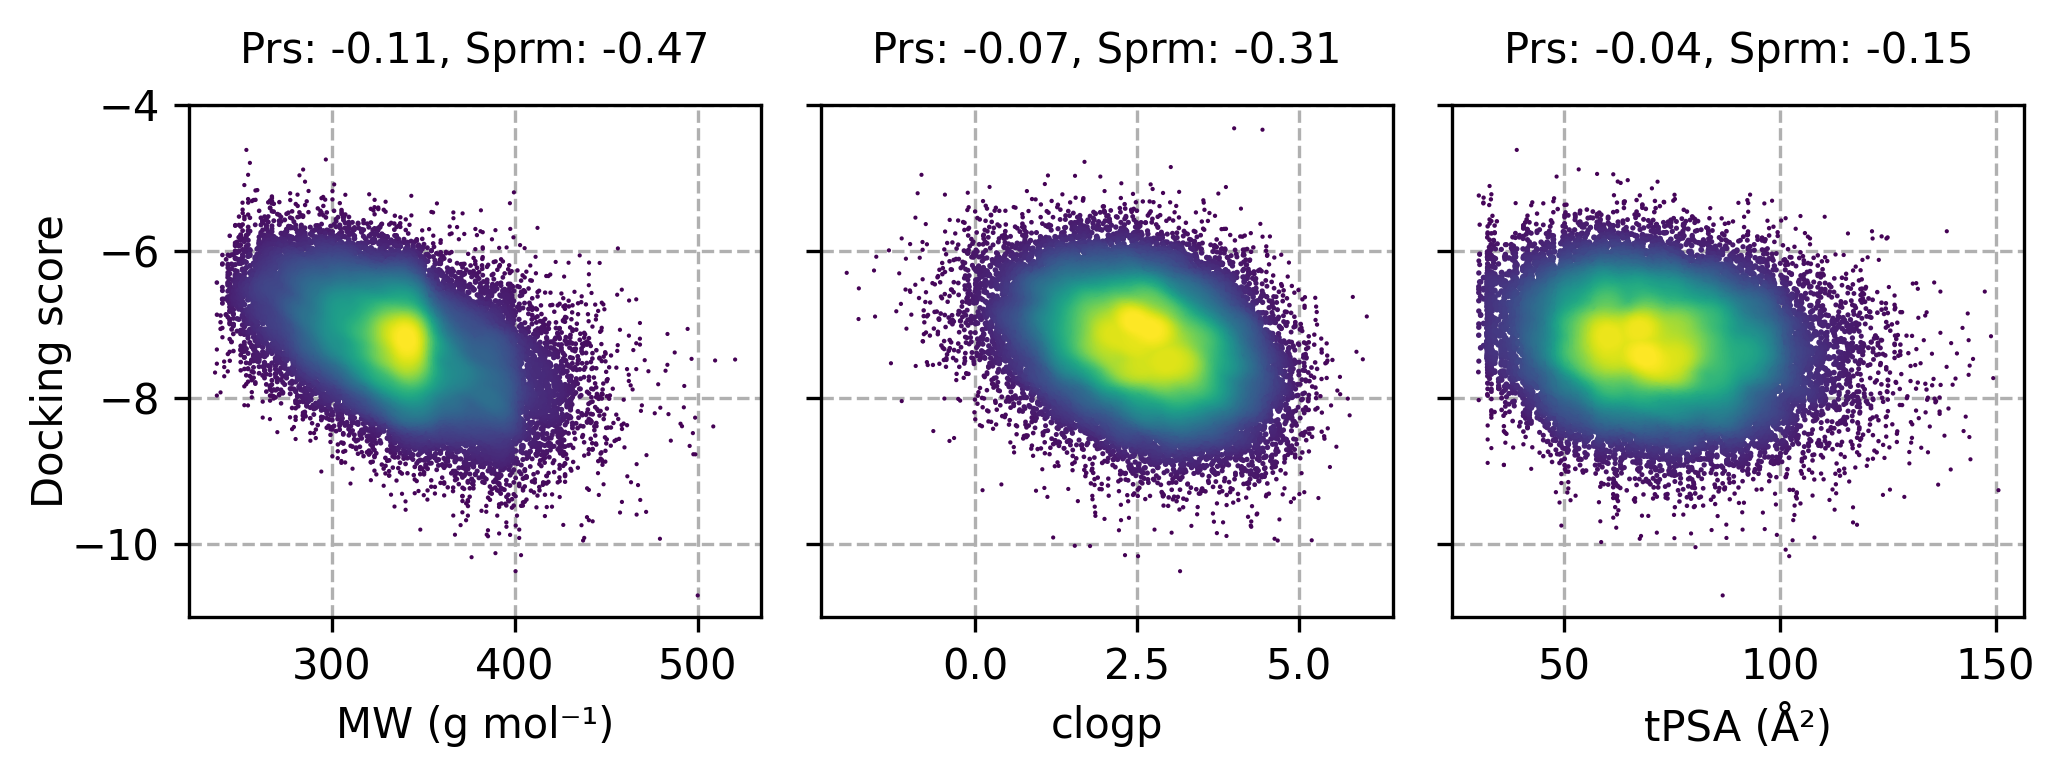

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(7, 2.7), sharey=True)

pocket = "alphafold2_P9WFS9_model_0_pocket_2"

# MW vs Docking score
coords = np.array([[ID_TO_MW[id_], ST_TO_DOCKING_SCORE[pocket][id_]] for id_ in sorted(ID_TO_MW) 
                   if id_ in ST_TO_DOCKING_SCORE[pocket]])
r_samp = np.random.choice(np.arange(len(coords)), size=20000, replace=False)
x, y, colors, sizes = calculate_density(coords[r_samp][:, 0], coords[r_samp][:, 1], bandwidth=0.15)
ax[0].scatter(x, y, s=sizes, c=colors, lw=0, zorder=2)
ax[0].set_ylim([-11, -4])
ax[0].set_xlabel("MW (g mol⁻¹)", size=10)
prs, spr = ss.pearsonr(coords[:, 0], coords[:, 1]).statistic, ss.spearmanr(coords[:, 0], coords[:, 1]).statistic
ax[0].set_title(f"Prs: {round(prs, 2)}, Sprm: {round(spr, 2)}", size=10, pad=10)

# clogp vs Docking score
coords = np.array([[ID_TO_LOGP[id_], ST_TO_DOCKING_SCORE[pocket][id_]] for id_ in sorted(ID_TO_LOGP) 
                   if id_ in ST_TO_DOCKING_SCORE[pocket]])
r_samp = np.random.choice(np.arange(len(coords)), size=20000, replace=False)
x, y, colors, sizes = calculate_density(coords[r_samp][:, 0], coords[r_samp][:, 1], bandwidth=0.15)
ax[1].scatter(x, y, s=sizes, c=colors, lw=0, zorder=2)
ax[1].set_xlabel("clogp", size=10)
prs, spr = ss.pearsonr(coords[:, 0], coords[:, 1]).statistic, ss.spearmanr(coords[:, 0], coords[:, 1]).statistic
ax[1].set_title(f"Prs: {round(prs, 2)}, Sprm: {round(spr, 2)}", size=10, pad=10)

# tPSA vs Docking score
coords = np.array([[ID_TO_TPSA[id_], ST_TO_DOCKING_SCORE[pocket][id_]] for id_ in sorted(ID_TO_TPSA) 
                   if id_ in ST_TO_DOCKING_SCORE[pocket]])
r_samp = np.random.choice(np.arange(len(coords)), size=20000, replace=False)
x, y, colors, sizes = calculate_density(coords[r_samp][:, 0], coords[r_samp][:, 1], bandwidth=0.15)
ax[2].scatter(x, y, s=sizes, c=colors, lw=0, zorder=2)
ax[2].set_xlabel("tPSA (Å²)", size=10)
prs, spr = ss.pearsonr(coords[:, 0], coords[:, 1]).statistic, ss.spearmanr(coords[:, 0], coords[:, 1]).statistic
ax[2].set_title(f"Prs: {round(prs, 2)}, Sprm: {round(spr, 2)}", size=10, pad=10)


ax[0].set_ylabel("Docking score", labelpad=0, size=10)
ax[0].grid(linestyle='--', zorder=-2)
ax[1].grid(linestyle='--', zorder=-2)
ax[2].grid(linestyle='--', zorder=-2)
plt.tight_layout()
plt.show()

In [8]:
smiles_list = [i for i in sorted(ST_TO_DOCKING_SCORE[pocket], key=lambda x: ST_TO_DOCKING_SCORE[pocket][x]) if i in ID_TO_SMI]
smiles_list = [ID_TO_SMI[i] for i in smiles_list[:100]]

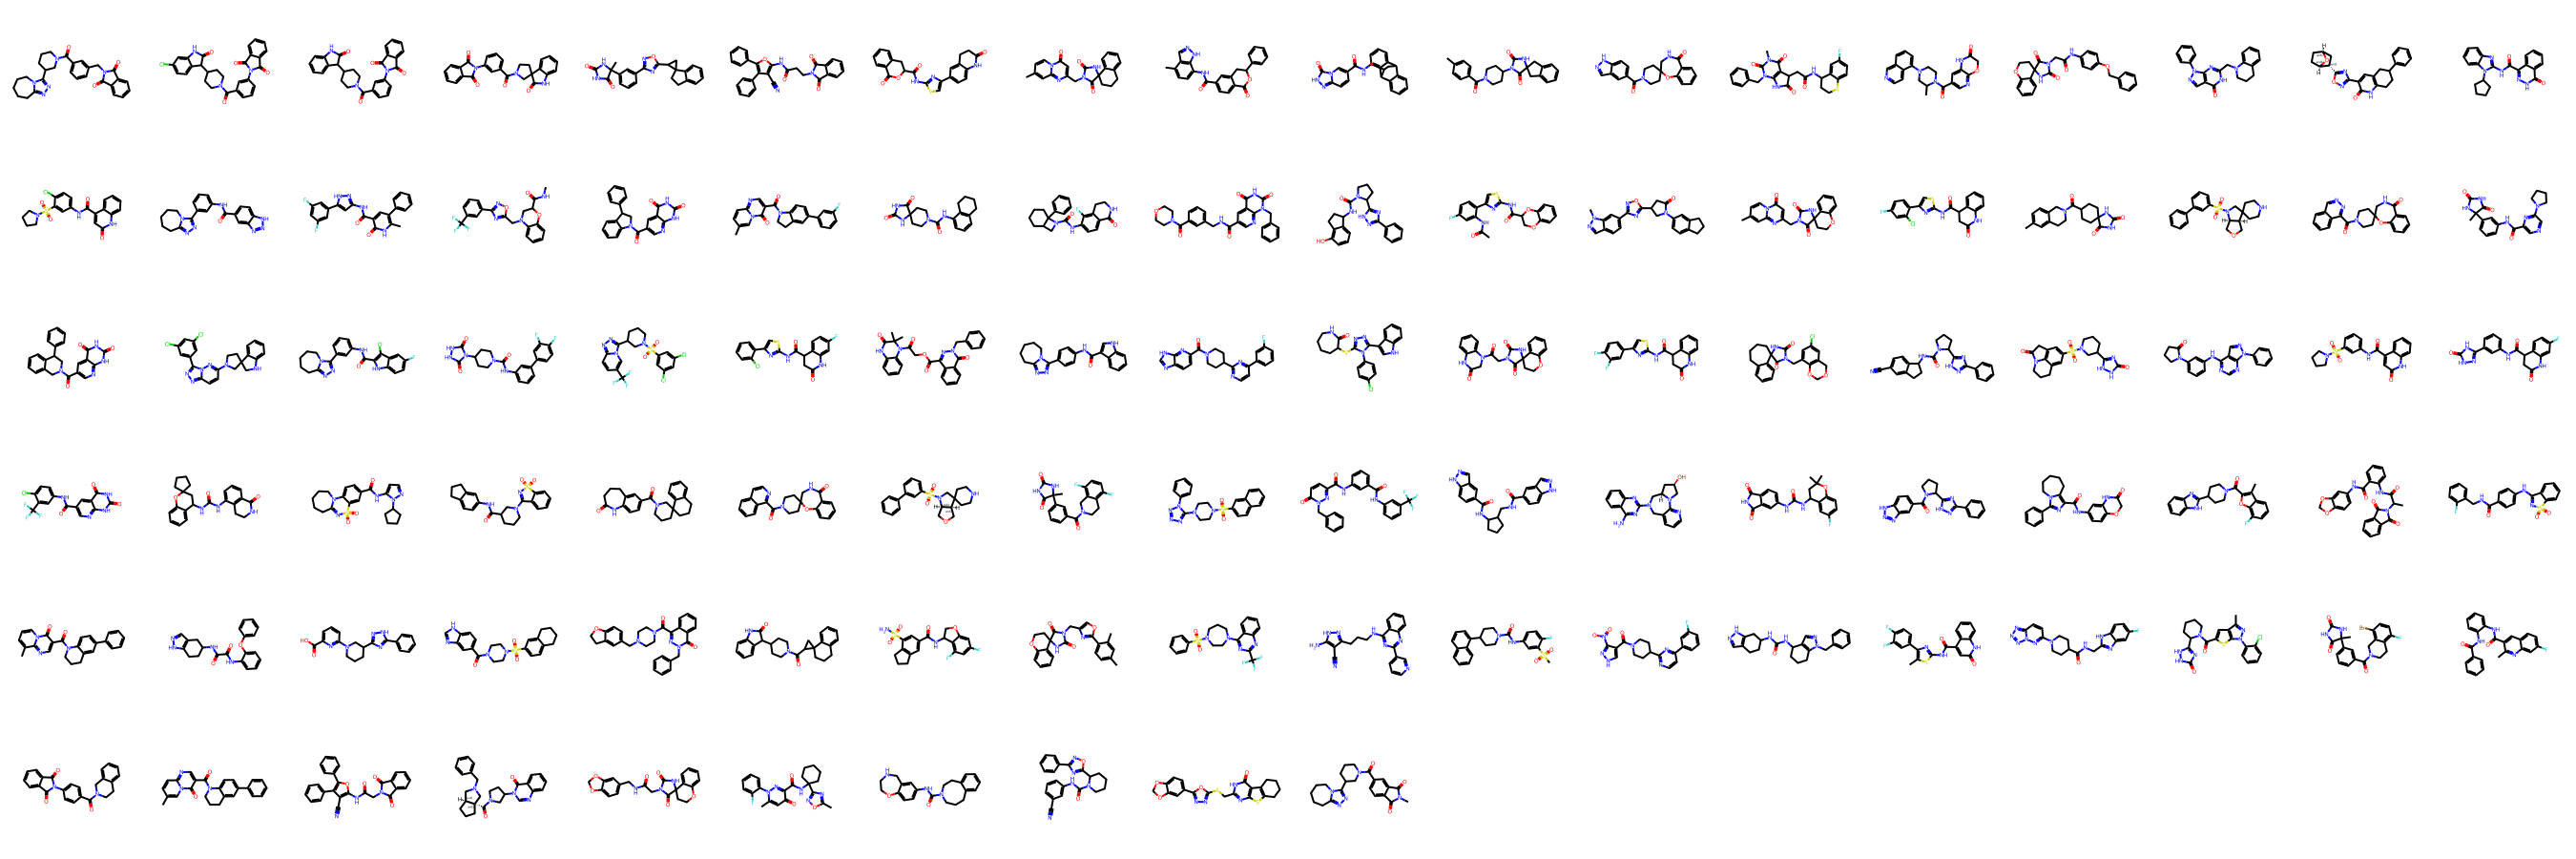

In [9]:
from IPython.display import display

# Convert SMILES to RDKit molecule objects
mols = [Chem.MolFromSmiles(smiles) for smiles in smiles_list]

# Create image grid
img = Draw.MolsToGridImage(
    mols,
    maxMols=1000000,
    molsPerRow=18,
    subImgSize=(150, 150)
)

display(img)

In [44]:
### CORRELATIONS ###
pearson_MW, spearman_MW = [], []
pearson_clogp, spearman_clogp = [], []
pearson_tPSA, spearman_tPSA = [], []

for pocket in tqdm(sorted(ST_TO_DOCKING_SCORE)):

    # Molecular weight
    coords = np.array([[ID_TO_MW[id_], ST_TO_DOCKING_SCORE[pocket][id_]] for id_ in sorted(ID_TO_MW)
                          if id_ in ST_TO_DOCKING_SCORE[pocket]])
    prs, spr = ss.pearsonr(coords[:, 0], coords[:, 1]).statistic, ss.spearmanr(coords[:, 0], coords[:, 1]).statistic
    pearson_MW.append(prs)
    spearman_MW.append(spr)

    # clogp
    coords = np.array([[ID_TO_LOGP[id_], ST_TO_DOCKING_SCORE[pocket][id_]] for id_ in sorted(ID_TO_LOGP)
                          if id_ in ST_TO_DOCKING_SCORE[pocket]])
    prs, spr = ss.pearsonr(coords[:, 0], coords[:, 1]).statistic, ss.spearmanr(coords[:, 0], coords[:, 1]).statistic
    pearson_clogp.append(prs)
    spearman_clogp.append(spr)  

    # tPSA
    coords = np.array([[ID_TO_TPSA[id_], ST_TO_DOCKING_SCORE[pocket][id_]] for id_ in sorted(ID_TO_TPSA)
                          if id_ in ST_TO_DOCKING_SCORE[pocket]])
    prs, spr = ss.pearsonr(coords[:, 0], coords[:, 1]).statistic, ss.spearmanr(coords[:, 0], coords[:, 1]).statistic
    pearson_tPSA.append(prs)
    spearman_tPSA.append(spr)   

100%|██████████| 276/276 [02:00<00:00,  2.30it/s]


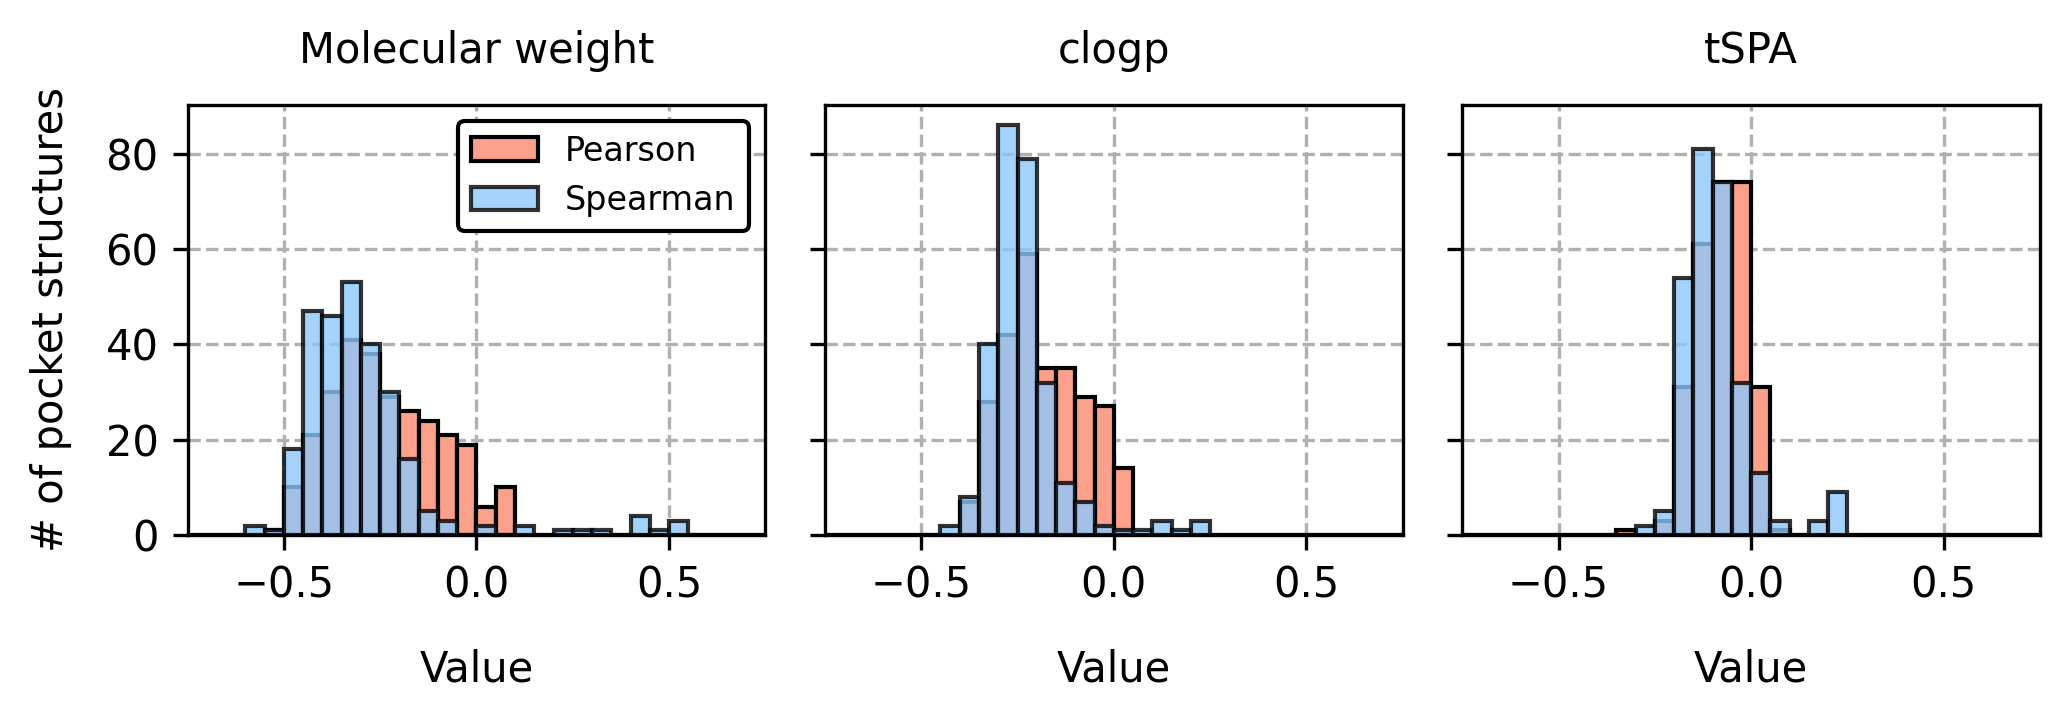

In [56]:
fig, ax = plt.subplots(1, 3, figsize=(7, 2.5), sharey=True)

bins = np.linspace(-1, 1, 41)

# Molecular weight
ax[0].hist(pearson_MW, bins=bins, edgecolor='k', color='#FAA08B', zorder=2, label='Pearson')
ax[0].hist(spearman_MW, bins=bins, edgecolor='k', color='#8DC7FA', zorder=2, label='Spearman', alpha=0.8)
ax[0].grid(linestyle='--', zorder=-2)
ax[0].set_xlabel("Value", labelpad=10)
ax[0].set_ylabel("# of pocket structures", labelpad=8)
ax[0].set_xticks([-1, -0.5, 0, 0.5, 1])
ax[0].legend(framealpha=1, edgecolor='k', prop={'size': 8})
ax[0].set_title("Molecular weight", size=10, pad=10)
ax[0].set_xlim(-0.75, 0.75)

# Logp
ax[1].hist(pearson_clogp, bins=bins, edgecolor='k', color='#FAA08B', zorder=2, label='Pearson')
ax[1].hist(spearman_clogp, bins=bins, edgecolor='k', color='#8DC7FA', zorder=2, label='Spearman', alpha=0.8)
ax[1].grid(linestyle='--', zorder=-2)
ax[1].set_xlabel("Value", labelpad=10)
ax[1].set_xticks([-1, -0.5, 0, 0.5, 1])
ax[1].set_title("clogp", size=10, pad=10)
ax[1].set_xlim(-0.75, 0.75)
# tSPA
ax[2].hist(pearson_tPSA, bins=bins, edgecolor='k', color='#FAA08B', zorder=2, label='Pearson')
ax[2].hist(spearman_tPSA, bins=bins, edgecolor='k', color='#8DC7FA', zorder=2, label='Spearman', alpha=0.8)
ax[2].grid(linestyle='--', zorder=-2)
ax[2].set_xlabel("Value", labelpad=10)
ax[2].set_xticks([-1, -0.5, 0, 0.5, 1])
ax[2].set_title("tSPA", size=10, pad=10)
ax[2].set_xlim(-0.75, 0.75)

plt.tight_layout()
plt.show()
